# Symmetric In-phase 


$$ 
 \frac{r_{A1} + r_{A2}}{2} = r_B , \quad r_{A1} > r_B , \quad r_{A2} < r_B
$$ 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties 
 
# Functions 

def f_1(n_1, n_2, t, r_A1, r_A2, r_B, d_A, d_B, alpha):
    return (((d_B * (1 - n_1) * ((1 - alpha) * r_A1 * n_1 + alpha * r_A2 * n_2)) - (r_B * d_A * n_1 * (1 - ((1 - alpha) * n_1 + alpha * n_2)))) /
            (((d_A - d_B) * (n_1 + n_2) + 2 * d_B) * (((r_A1 - r_B) * (1 - alpha) * n_1 + (r_A2 - r_B) * alpha * n_2) + r_B)))
def f_2(n_2, n_1, t, r_A1, r_A2, r_B, d_A, d_B, beta):
    return (((d_B * (1 - n_2) * ((1 - beta) * r_A2 * n_2 + beta * r_A1 * n_1)) - (r_B * d_A * n_2 * (1 - ((1 - beta) * n_2 + beta * n_1)))) /
            (((d_A - d_B) * (n_1 + n_2) + 2 * d_B) * (((r_A2 - r_B) * (1 - beta) * n_2 + (r_A1 - r_B) * beta * n_1) + r_B)))

# Parameters
T_values = [ 1 , 5, 10, 20, 30, 50, 100, 200, 300, 500, 1000, 1500, 2000, 3000, 4000, 5000, 10000 , 15000 , 20000 ]
n01 = 0.01
n02 = 0.00
t0 = 0.0
tf = 100000
r_B = 1
d_A = 1
d_B = 1
dt = 0.1 
alpha_0_values = [0.15, 0.2, 0.3]
num_steps = int((tf - t0) / dt)
r_A1_values = [1.1, 1.2, 1.3]
markers = {0.15: 'o', 0.2: 'd', 0.3: 'x'}
colors = {(1.1, 0.9): (1.0, 0.0, 0.0), (1.2, 0.8): (0.0, 1.0, 0.0), (1.3, 0.7): (0.0, 0.0, 1.0)}

# Define distinct dash styles and colors 

dash_styles = {0.15: (0, (5, 1)), 0.2: (0, (3, 5, 1, 5)), 0.3: (0, (1, 1))}
const_colors = {
    (1.1, 0.9, 0.15): (1.0, 0.0, 0.0),  
    (1.1, 0.9, 0.2): (1.0, 0.0, 0.0),    
    (1.1, 0.9, 0.3): (1.0, 0.0, 0.0),   
    (1.2, 0.8, 0.15): (0.0, 1.0, 0.0),   
    (1.2, 0.8, 0.2): (0.0, 1.0, 0.0),    
    (1.2, 0.8, 0.3): (0.0, 1.0, 0.0),    
    (1.3, 0.7, 0.15): (0.0, 0.0, 1.0),   
    (1.3, 0.7, 0.2): (0.0, 0.0, 1.0),    
    (1.3, 0.7, 0.3): (0.0, 0.0, 1.0)     
}

# Different x-positions for the infinity symbol per color group

inf_positions = {
    (1.0, 0.0, 0.0): max(T_values) * 1.5,  
    (0.0, 1.0, 0.0): max(T_values) * 2,   
    (0.0, 0.0, 1.0): max(T_values) * 2.5    
}

# Dynamics 
plt.figure(figsize=(12, 8))
for r_A1 in r_A1_values:
    r_A2 = 2 - r_A1
    r_A1_rounded = round(r_A1, 3)
    r_A2_rounded = round(r_A2, 3)
    color = colors[(r_A1_rounded, r_A2_rounded)]

    for alpha_0 in alpha_0_values:

       
        t = np.linspace(t0, tf, num_steps)
        alpha_const = np.full(num_steps, alpha_0)
        beta_const = np.full(num_steps, alpha_0)
        n_1_const = np.zeros(num_steps)
        n_2_const = np.zeros(num_steps)
        n_1_const[0] = n01
        n_2_const[0] = n02
        for i in range(1, num_steps):
            n_1_const[i] = n_1_const[i-1] + f_1(n_1_const[i-1], n_2_const[i-1], t[i-1], r_A1, r_A2, r_B, d_A, d_B, alpha_const[i-1]) * dt
            n_2_const[i] = n_2_const[i-1] + f_2(n_2_const[i-1], n_1_const[i-1], t[i-1], r_A1, r_A2, r_B, d_A, d_B, beta_const[i-1]) * dt
        y_const = (n_1_const + n_2_const) / 2
        time_range = (t >= 60000) & (t <= tf)
        y_range_const = y_const[time_range]
        min_y_const = np.min(y_range_const)
        max_y_const = np.max(y_range_const)
        limiting = (max_y_const + min_y_const) / 2

        
        average_of_averages = []
        for T in T_values:
            t = np.linspace(t0, tf, num_steps)
            alpha = alpha_0 * (np.cos((np.pi * t) / T))**2
            beta = alpha_0 * (np.cos((np.pi * t) / T))**2
            n_1 = np.zeros(num_steps)
            n_2 = np.zeros(num_steps)
            n_1[0] = n01
            n_2[0] = n02
            for i in range(1, num_steps):
                n_1[i] = n_1[i-1] + f_1(n_1[i-1], n_2[i-1], t[i-1], r_A1, r_A2, r_B, d_A, d_B, alpha[i-1]) * dt
                n_2[i] = n_2[i-1] + f_2(n_2[i-1], n_1[i-1], t[i-1], r_A1, r_A2, r_B, d_A, d_B, beta[i-1]) * dt
            y = (n_1 + n_2) / 2
            time_range = (t >= 60000) & (t <= tf)
            y_range = y[time_range]
            min_y = np.min(y_range)
            max_y = np.max(y_range)
            Avg = (max_y + min_y) / 2
            average_of_averages.append(Avg)

        plt.scatter((T_values), average_of_averages, marker=markers[alpha_0], color=color, label=f'Delta_r ={round(r_A1_rounded - r_A2_rounded , 3)}')

        plt.plot((T_values), average_of_averages , color = color , linestyle=dash_styles[alpha_0] )
        
        
        const_color = const_colors[(r_A1_rounded, r_A2_rounded, alpha_0)]

        plt.axhline(y=limiting, color=const_color, linestyle=dash_styles[alpha_0], alpha=0.7) # , label=f'Constant migration (T→∞, α={alpha_0}, β={alpha_0}) for r_A1={r_A1_rounded}, r_A2={r_A2_rounded}')

        inf_x = inf_positions[const_color]
        plt.scatter(inf_x, limiting, marker=r'$\infty$', color=const_color, s=120)

font = FontProperties(family='serif', style='italic', math_fontfamily='stix', size=18)
plt.xscale('log')
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)


max_inf = max(inf_positions.values())
plt.xlim(-1 , max_inf * 1.4)
plt.ylim(0.5 , 0.75)
plt.xlabel(r'$T$' , fontproperties=font)
plt.ylabel(r'$\bar\phi$' , fontproperties=font)

plt.tight_layout() 
plt.show()

# Symmetric Out-of-phase

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# functions 

def f_1(n_1, n_2, t, r_A1, r_A2, r_B, d_A, d_B, alpha):
    return (((d_B * (1 - n_1) * ((1 - alpha) * r_A1 * n_1 + alpha * r_A2 * n_2)) -
             (r_B * d_A * n_1 * (1 - ((1 - alpha) * n_1 + alpha * n_2)))) /
            (((d_A - d_B) * (n_1 + n_2) + 2 * d_B) *
             (((r_A1 - r_B) * (1 - alpha) * n_1 + (r_A2 - r_B) * alpha * n_2) + r_B)))

def f_2(n_2, n_1, t, r_A1, r_A2, r_B, d_A, d_B, beta):
    return (((d_B * (1 - n_2) * ((1 - beta) * r_A2 * n_2 + beta * r_A1 * n_1)) -
             (r_B * d_A * n_2 * (1 - ((1 - beta) * n_2 + beta * n_1)))) /
            (((d_A - d_B) * (n_1 + n_2) + 2 * d_B) *
             (((r_A2 - r_B) * (1 - beta) * n_2 + (r_A1 - r_B) * beta * n_1) + r_B)))


# Parameters

T_values   = [1, 5, 10, 20, 30, 50, 100, 200, 300, 500, 1000, 1500, 2000, 3000, 4000, 5000, 10000 , 15000 , 20000]

n01 = 0.01
n02 = 0.00
t0  = 0.0
tf  = 100000
dt  = 0.1
num_steps = int((tf - t0) / dt)
r_B = 1
d_A = 1
d_B = 1
alpha_0_values = [0.15, 0.2, 0.3]
r_A1_values    = [1.1, 1.2, 1.3]

# Define distinct dash styles and colors 

markers = {0.15: 'o', 0.2: 'd', 0.3: 'x'}
colors  = {(1.1, 0.9): (1.0, 0.0, 0.0),
           (1.2, 0.8): (0.0, 1.0, 0.0),
           (1.3, 0.7): (0.0, 0.0, 1.0)}

dash_styles = {0.15: (0, (5, 1)), 0.2: (0, (3, 5, 1, 5)), 0.3: (0, (1, 1))} 


# Dynamics 

plt.figure(figsize=(12, 8))

for r_A1 in r_A1_values:
    r_A2 = 2 - r_A1
    r_A1_r = round(r_A1, 3)
    r_A2_r = round(r_A2, 3)
    color = colors[(r_A1_r, r_A2_r)]

    for alpha_0 in alpha_0_values:
        average_of_averages = []

        for T in T_values:
            
            t = np.linspace(t0, tf, num_steps)

            
            alpha = alpha_0 * (np.cos(np.pi * t / T))**2
            beta  = alpha_0 * (np.sin(np.pi * t / T))**2

           
            n_1 = np.zeros(num_steps)
            n_2 = np.zeros(num_steps)
            n_1[0] = n01
            n_2[0] = n02

            for i in range(1, num_steps):
                n_1[i] = n_1[i-1] + f_1(n_1[i-1], n_2[i-1], t[i-1],
                                        r_A1, r_A2, r_B, d_A, d_B, alpha[i-1]) * dt
                n_2[i] = n_2[i-1] + f_2(n_2[i-1], n_1[i-1], t[i-1],
                                        r_A1, r_A2, r_B, d_A, d_B, beta[i-1]) * dt

            y = (n_1 + n_2) / 2
            time_range = (t >= 60000) & (t <= tf)
            y_range = y[time_range]
            min_y = np.min(y_range)
            max_y = np.max(y_range)
            Avg = (max_y + min_y) / 2
            average_of_averages.append(Avg)
            
        
        plt.scatter(T_values, average_of_averages,
                    marker=markers[alpha_0], color=color) 
        
        plt.plot((T_values), average_of_averages , color = color , linestyle=dash_styles[alpha_0] )
        
plt.xscale('log')
plt.ylim(0.48 , 0.60)
plt.xlabel(r'$T$' , fontsize = 15 )
plt.ylabel(r'$\bar\phi$' , fontsize = 15)
plt.show()

# Symmetric In-phase

$$ 
\frac{r_{A1} + r_{A2}}{2} < r_{B} ,\qquad  r_{A1} > r_B ,\qquad r_{A2} < r_B 
$$  

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties

# functions 

def f_1(n_1, n_2, t, r_A1, r_A2, r_B, d_A, d_B, alpha):
    return (((d_B * (1 - n_1) * ((1 - alpha) * r_A1 * n_1 + alpha * r_A2 * n_2)) -
             (r_B * d_A * n_1 * (1 - ((1 - alpha) * n_1 + alpha * n_2)))) /
            (((d_A - d_B) * (n_1 + n_2) + 2 * d_B) *
             (((r_A1 - r_B) * (1 - alpha) * n_1 + (r_A2 - r_B) * alpha * n_2) + r_B)))

def f_2(n_2, n_1, t, r_A1, r_A2, r_B, d_A, d_B, beta):
    return (((d_B * (1 - n_2) * ((1 - beta) * r_A2 * n_2 + beta * r_A1 * n_1)) -
             (r_B * d_A * n_2 * (1 - ((1 - beta) * n_2 + beta * n_1)))) /
            (((d_A - d_B) * (n_1 + n_2) + 2 * d_B) *
             (((r_A2 - r_B) * (1 - beta) * n_2 + (r_A1 - r_B) * beta * n_1) + r_B)))

# Parameters
T_values = [1, 5, 10, 20, 30, 50, 100, 200, 300, 500, 1000, 1500, 2000, 3000, 4000, 5000, 10000, 15000, 20000]
n01 = 0.01
n02 = 0.00
t0 = 0.0
tf = 100000
r_B = 1
d_A = 1
d_B = 1
dt = 0.1
alpha_0_values = [0.15, 0.2, 0.3]
num_steps = int((tf - t0) / dt)
r_A1_values = [1.1, 1.2, 1.3]

# Define distinct dash styles and colors 

markers = {0.15: 'o', 0.2: 'd', 0.3: 'x'}

colors = {
    (1.1, 0.4): (1.0, 0.0, 0.0),   
    (1.2, 0.3): (0.0, 1.0, 0.0),   
    (1.3, 0.2): (0.0, 0.0, 1.0)    
}

dash_styles = {
    0.15: (0, (5, 1)),
    0.2:  (0, (3, 5, 1, 5)),
    0.3:  (0, (1, 1))
}

const_colors = {
    (1.1, 0.4, 0.15): (1.0, 0.0, 0.0),
    (1.1, 0.4, 0.2):  (1.0, 0.0, 0.0),
    (1.1, 0.4, 0.3):  (1.0, 0.0, 0.0),
    (1.2, 0.3, 0.15): (0.0, 1.0, 0.0),
    (1.2, 0.3, 0.2):  (0.0, 1.0, 0.0),
    (1.2, 0.3, 0.3):  (0.0, 1.0, 0.0),
    (1.3, 0.2, 0.15): (0.0, 0.0, 1.0),
    (1.3, 0.2, 0.2):  (0.0, 0.0, 1.0),
    (1.3, 0.2, 0.3):  (0.0, 0.0, 1.0)
}

# Different x-positions for the infinity symbol per color group
inf_positions = {
    (1.0, 0.0, 0.0): max(T_values) * 1.5,   
    (0.0, 1.0, 0.0): max(T_values) * 2,   
    (0.0, 0.0, 1.0): max(T_values) * 2.5    
}

plt.figure(figsize=(12, 8))

for r_A1 in r_A1_values:
    r_A2 = 1.5 - r_A1
    r_A1_rounded = round(r_A1, 3)
    r_A2_rounded = round(r_A2, 3)
    color = colors[(r_A1_rounded, r_A2_rounded)]

    for alpha_0 in alpha_0_values:
        
        t = np.linspace(t0, tf, num_steps)
        alpha_const = np.full(num_steps, alpha_0)
        beta_const  = np.full(num_steps, alpha_0)

        n_1_const = np.zeros(num_steps)
        n_2_const = np.zeros(num_steps)
        n_1_const[0] = n01
        n_2_const[0] = n02

        for i in range(1, num_steps):
            n_1_const[i] = n_1_const[i-1] + f_1(n_1_const[i-1], n_2_const[i-1], t[i-1], r_A1, r_A2, r_B, d_A, d_B, alpha_const[i-1]) * dt
            n_2_const[i] = n_2_const[i-1] + f_2(n_2_const[i-1], n_1_const[i-1], t[i-1], r_A1, r_A2, r_B, d_A, d_B, beta_const[i-1]) * dt

        y_const = (n_1_const + n_2_const) / 2
        time_range = (t >= 60000) & (t <= tf)
        y_range_const = y_const[time_range]
        limiting = (np.min(y_range_const) + np.max(y_range_const)) / 2

        
        average_of_averages = []
        for T in T_values:
            alpha = alpha_0 * (np.cos((np.pi * t) / T))**2
            beta  = alpha_0 * (np.cos((np.pi * t) / T))**2

            n_1 = np.zeros(num_steps)
            n_2 = np.zeros(num_steps)
            n_1[0] = n01
            n_2[0] = n02

            for i in range(1, num_steps):
                n_1[i] = n_1[i-1] + f_1(n_1[i-1], n_2[i-1], t[i-1], r_A1, r_A2, r_B, d_A, d_B, alpha[i-1]) * dt
                n_2[i] = n_2[i-1] + f_2(n_2[i-1], n_1[i-1], t[i-1], r_A1, r_A2, r_B, d_A, d_B, beta[i-1]) * dt

            y = (n_1 + n_2) / 2
            y_range = y[time_range]
            Avg = (np.min(y_range) + np.max(y_range)) / 2
            average_of_averages.append(Avg)

        
        plt.scatter(T_values, average_of_averages, marker=markers[alpha_0], color=color)
        plt.plot(T_values, average_of_averages, color=color, linestyle=dash_styles[alpha_0])

        
        const_color = const_colors[(r_A1_rounded, r_A2_rounded, alpha_0)]
        plt.axhline(y=limiting, color=const_color, linestyle=dash_styles[alpha_0], alpha=0.7)

        inf_x = inf_positions[const_color]
        plt.scatter(inf_x, limiting, marker=r'$\infty$', color=const_color, s=120)


font = FontProperties(family='serif', style='italic', math_fontfamily='stix', size=18)

plt.xscale('log')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

max_inf = max(inf_positions.values())
plt.xlim(-1 , max_inf * 1.4)

plt.xlabel(r'$T$', fontproperties=font)
plt.ylabel(r'$\bar\phi$', fontproperties=font)


plt.tight_layout()
plt.show()

# Symmetric Out-of-phase 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties

# functions 

def f_1(n_1, n_2, t, r_A1, r_A2, r_B, d_A, d_B, alpha):
    return (((d_B * (1 - n_1) * ((1 - alpha) * r_A1 * n_1 + alpha * r_A2 * n_2)) -
             (r_B * d_A * n_1 * (1 - ((1 - alpha) * n_1 + alpha * n_2)))) /
            (((d_A - d_B) * (n_1 + n_2) + 2 * d_B) *
             (((r_A1 - r_B) * (1 - alpha) * n_1 + (r_A2 - r_B) * alpha * n_2) + r_B)))

def f_2(n_2, n_1, t, r_A1, r_A2, r_B, d_A, d_B, beta):
    return (((d_B * (1 - n_2) * ((1 - beta) * r_A2 * n_2 + beta * r_A1 * n_1)) -
             (r_B * d_A * n_2 * (1 - ((1 - beta) * n_2 + beta * n_1)))) /
            (((d_A - d_B) * (n_1 + n_2) + 2 * d_B) *
             (((r_A2 - r_B) * (1 - beta) * n_2 + (r_A1 - r_B) * beta * n_1) + r_B)))


# Parameters

T_values   = [1, 5, 10, 20, 30, 50, 100, 200, 300, 500,
              1000, 1500, 2000, 3000, 4000, 5000, 10000 , 15000 , 20000]

n01 = 0.01
n02 = 0.00
t0  = 0.0
tf  = 100000
dt  = 0.1
num_steps = int((tf - t0) / dt)
r_B = 1
d_A = 1
d_B = 1

alpha_0_values = [0.15, 0.2, 0.3]
r_A1_values    = [1.1, 1.2, 1.3]

markers = {0.15: 'o', 0.2: 'd', 0.3: 'x'}
colors  = {(1.1, 0.4): (1.0, 0.0, 0.0),
           (1.2, 0.3): (0.0, 1.0, 0.0),
           (1.3, 0.2): (0.0, 0.0, 1.0)}
dash_styles = {
    0.15: (0, (5, 1)),
    0.2:  (0, (3, 5, 1, 5)),
    0.3:  (0, (1, 1))
}

# Plot

plt.figure(figsize=(12, 8))

for r_A1 in r_A1_values:
    r_A2 = 1.5 - r_A1
    r_A1_r = round(r_A1, 3)
    r_A2_r = round(r_A2, 3)
    col = colors[(r_A1_r, r_A2_r)]

    for alpha_0 in alpha_0_values:
        average_of_averages = []

        for T in T_values:
           
            t = np.linspace(t0, tf, num_steps)

            
            alpha = alpha_0 * (np.cos(np.pi * t / T))**2
            beta  = alpha_0 * (np.sin(np.pi * t / T))**2

            
            n_1 = np.zeros(num_steps)
            n_2 = np.zeros(num_steps)
            n_1[0] = n01
            n_2[0] = n02

            for i in range(1, num_steps):
                n_1[i] = n_1[i-1] + f_1(n_1[i-1], n_2[i-1], t[i-1],
                                        r_A1, r_A2, r_B, d_A, d_B, alpha[i-1]) * dt
                n_2[i] = n_2[i-1] + f_2(n_2[i-1], n_1[i-1], t[i-1],
                                        r_A1, r_A2, r_B, d_A, d_B, beta[i-1]) * dt

            
            y = (n_1 + n_2) / 2
            mask = (t >= 60000) & (t <= tf)
            y_part = y[mask]
            avg = (y_part.min() + y_part.max()) / 2
            average_of_averages.append(avg)

        
        plt.scatter(T_values, average_of_averages,
                    marker=markers[alpha_0], color=col)
                    
        
        plt.plot(T_values, average_of_averages,
                    linestyle=dash_styles[alpha_0], color=col)
                    
font = FontProperties(family='serif', style='italic', math_fontfamily='stix', size=18)

plt.xscale('log')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.xlabel(r'$T$', fontproperties=font)
plt.ylabel(r'$\bar\phi$', fontproperties=font)

plt.tight_layout()
plt.show()

# Symmetric In-phase 

$$ 
\frac{r_{A1} + r_{A2}}{2} > r_{B} ,\qquad  r_{A1} > r_B ,\qquad r_{A2} <= r_B 
$$  

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties

# Functions
def f_1(n_1, n_2, t, r_A1, r_A2, r_B, d_A, d_B, alpha):
    return (((d_B * (1 - n_1) * ((1 - alpha) * r_A1 * n_1 + alpha * r_A2 * n_2)) -
             (r_B * d_A * n_1 * (1 - ((1 - alpha) * n_1 + alpha * n_2)))) /
            (((d_A - d_B) * (n_1 + n_2) + 2 * d_B) *
             (((r_A1 - r_B) * (1 - alpha) * n_1 + (r_A2 - r_B) * alpha * n_2) + r_B)))

def f_2(n_2, n_1, t, r_A1, r_A2, r_B, d_A, d_B, beta):
    return (((d_B * (1 - n_2) * ((1 - beta) * r_A2 * n_2 + beta * r_A1 * n_1)) -
             (r_B * d_A * n_2 * (1 - ((1 - beta) * n_2 + beta * n_1)))) /
            (((d_A - d_B) * (n_1 + n_2) + 2 * d_B) *
             (((r_A2 - r_B) * (1 - beta) * n_2 + (r_A1 - r_B) * beta * n_1) + r_B)))


T_values = [1, 5, 10, 20, 30, 50, 100, 200, 300, 500,
            1000, 1500, 2000, 3000, 4000, 5000, 10000, 15000, 20000]

n01 = 0.01
n02 = 0.00
t0 = 0.0
tf = 100000
dt = 0.1
num_steps = int((tf - t0) / dt)

r_B = 1
d_A = 1
d_B = 1

alpha_0_values = [0.15, 0.2, 0.3]
r_A1_values = [1.5, 1.6, 1.7]


markers = {0.15: 'o', 0.2: 'd', 0.3: 'x'}
colors = {
    (1.5, 1.0): (1.0, 0.0, 0.0),   
    (1.6, 0.9): (0.0, 0.7, 0.0),   
    (1.7, 0.8): (0.0, 0.0, 1.0)    
}
dash_styles = {
    0.15: (0, (5, 1)),
    0.2:  (0, (3, 5, 1, 5)),
    0.3:  (0, (1, 1))
}


const_colors = {}
for r_A1 in r_A1_values:
    r_A2 = 2.5 - r_A1
    r_A1_r = round(r_A1, 3)
    r_A2_r = round(r_A2, 3)
    base_color = colors[(r_A1_r, r_A2_r)]
    for alpha_0 in alpha_0_values:
        const_colors[(r_A1_r, r_A2_r, alpha_0)] = base_color

# Infinity symbol positions
inf_positions = {
    (1.0, 0.0, 0.0): max(T_values) * 1.5,
    (0.0, 0.7, 0.0): max(T_values) * 2.0,
    (0.0, 0.0, 1.0): max(T_values) * 2.5
}

plt.figure(figsize=(13, 8))

for r_A1 in r_A1_values:
    r_A2 = 2.5 - r_A1
    r_A1_r = round(r_A1, 3)
    r_A2_r = round(r_A2, 3)
    col = colors[(r_A1_r, r_A2_r)]

    for alpha_0 in alpha_0_values:
        t = np.linspace(t0, tf, num_steps)
        
        
        alpha_const = np.full(num_steps, alpha_0)
        beta_const = np.full(num_steps, alpha_0)

        n1c = np.zeros(num_steps)
        n2c = np.zeros(num_steps)
        n1c[0] = n01
        n2c[0] = n02

        for i in range(1, num_steps):
            n1c[i] = n1c[i-1] + f_1(n1c[i-1], n2c[i-1], t[i-1],
                                    r_A1, r_A2, r_B, d_A, d_B, alpha_const[i-1]) * dt
            n2c[i] = n2c[i-1] + f_2(n2c[i-1], n1c[i-1], t[i-1],
                                    r_A1, r_A2, r_B, d_A, d_B, beta_const[i-1]) * dt

        y_const = (n1c + n2c) / 2
        mask = (t >= 60000) & (t <= tf)
        lim_val = (y_const[mask].min() + y_const[mask].max()) / 2

        
        plt.axhline(lim_val, color=col, linestyle=dash_styles[alpha_0],
                    linewidth=1.2, alpha=0.75)

        
        inf_color = const_colors[(r_A1_r, r_A2_r, alpha_0)]
        inf_x = inf_positions[inf_color]
        plt.scatter(inf_x, lim_val, marker=r'$\infty$', color=inf_color, s=140, zorder=5)

        
        average_of_averages = []
        for T in T_values:
            cos_term = np.cos(np.pi * t / T)
            alpha = alpha_0 * cos_term**2
            beta = alpha_0 * cos_term**2

            n1 = np.zeros(num_steps)
            n2 = np.zeros(num_steps)
            n1[0] = n01
            n2[0] = n02

            for i in range(1, num_steps):
                n1[i] = n1[i-1] + f_1(n1[i-1], n2[i-1], t[i-1],
                                      r_A1, r_A2, r_B, d_A, d_B, alpha[i-1]) * dt
                n2[i] = n2[i-1] + f_2(n2[i-1], n1[i-1], t[i-1],
                                      r_A1, r_A2, r_B, d_A, d_B, beta[i-1]) * dt

            y = (n1 + n2) / 2
            y_part = y[mask]
            avg = (y_part.min() + y_part.max()) / 2
            average_of_averages.append(avg)

        
        plt.plot(T_values, average_of_averages, color=col,
                 linestyle=dash_styles[alpha_0], linewidth=1.5)
        plt.scatter(T_values, average_of_averages, marker=markers[alpha_0],
                    color=col, linewidth=0.6, s=50)


font = FontProperties(family='serif', style='italic', math_fontfamily='stix', size=18)

plt.xscale('log')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

max_inf = max(inf_positions.values())
plt.xlim(-1 , max_inf * 1.4)

plt.xlabel(r'$T$', fontproperties=font)
plt.ylabel(r'$\bar\phi$', fontproperties=font)


plt.tight_layout()
plt.show()

# Symmetric Out-of-phase 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties 


def f_1(n_1, n_2, t, r_A1, r_A2, r_B, d_A, d_B, alpha):
    return (((d_B * (1 - n_1) * ((1 - alpha) * r_A1 * n_1 + alpha * r_A2 * n_2)) -
             (r_B * d_A * n_1 * (1 - ((1 - alpha) * n_1 + alpha * n_2)))) /
            (((d_A - d_B) * (n_1 + n_2) + 2 * d_B) *
             (((r_A1 - r_B) * (1 - alpha) * n_1 + (r_A2 - r_B) * alpha * n_2) + r_B)))

def f_2(n_2, n_1, t, r_A1, r_A2, r_B, d_A, d_B, beta):
    return (((d_B * (1 - n_2) * ((1 - beta) * r_A2 * n_2 + beta * r_A1 * n_1)) -
             (r_B * d_A * n_2 * (1 - ((1 - beta) * n_2 + beta * n_1)))) /
            (((d_A - d_B) * (n_1 + n_2) + 2 * d_B) *
             (((r_A2 - r_B) * (1 - beta) * n_2 + (r_A1 - r_B) * beta * n_1) + r_B)))


T_values = [1, 5, 10, 20, 30, 50, 100, 200, 300, 500, 1000, 1500, 2000, 3000, 4000, 5000, 10000 , 15000 , 20000]

n01 = 0.01
n02 = 0.00
t0  = 0.0
tf  = 100000
dt  = 0.1
num_steps = int((tf - t0) / dt)

r_B = 1
d_A = 1
d_B = 1

alpha_0_values = [0.15, 0.2, 0.3]
r_A1_values    = [1.6, 1.7, 1.8]   

markers = {0.15: 'o', 0.2: 'd', 0.3: 'x'}
dash_styles = {0.15: (0, (5, 1)), 0.2: (0, (3, 5, 1, 5)), 0.3: (0, (1, 1))}
colors  = {
    (1.6, 0.9): (1.0, 0.0, 0.0),    
    (1.7, 0.8): (0.0, 1.0 , 0.0),   
    (1.8, 0.7): (0.0, 0.0, 1.0)     
}



plt.figure(figsize=(12, 8))

for r_A1 in r_A1_values:
    r_A2 = 2.5 - r_A1
    r_A1_rounded = round(r_A1, 3)
    r_A2_rounded = round(r_A2, 3)
    color = colors[(r_A1_rounded, r_A2_rounded)]

    for alpha_0 in alpha_0_values:
        average_of_averages = []

        for T in T_values:
            # Time vector
            t = np.linspace(t0, tf, num_steps)

            
            cos_term = np.cos(np.pi * t / T)
            sin_term = np.sin(np.pi * t / T)
            alpha = alpha_0 * cos_term**2
            beta  = alpha_0 * sin_term**2

            
            n_1 = np.zeros(num_steps)
            n_2 = np.zeros(num_steps)
            n_1[0] = n01
            n_2[0] = n02

            for i in range(1, num_steps):
                n_1[i] = n_1[i-1] + f_1(n_1[i-1], n_2[i-1], t[i-1],
                                        r_A1, r_A2, r_B, d_A, d_B, alpha[i-1]) * dt
                n_2[i] = n_2[i-1] + f_2(n_2[i-1], n_1[i-1], t[i-1],
                                        r_A1, r_A2, r_B, d_A, d_B, beta[i-1]) * dt

            
            y = (n_1 + n_2) / 2
            mask = (t >= 60000) & (t <= tf)
            y_part = y[mask]
            avg = (y_part.min() + y_part.max()) / 2
            average_of_averages.append(avg)

        
        plt.scatter((T_values), average_of_averages,
                    marker=markers[alpha_0], color=color)
        
        plt.plot((T_values), average_of_averages,color=color,linestyle = dash_styles[alpha_0] )


font = FontProperties(family='serif', style='italic', math_fontfamily='stix', size=18)
plt.xscale('log')
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.xlabel(r'$T$' , fontproperties=font)
plt.ylabel(r'$\bar\phi$' , fontproperties=font)

plt.show()

# Asymmetric In-phase -- More Migration towards deleterious island 

$$ 
 \frac{r_{A1} + r_{A2}}{2} = r_B , \quad r_{A1} > r_B , \quad r_{A2} < r_B
$$ 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties


def f_1(n_1, n_2, t, r_A1, r_A2, r_B, d_A, d_B, alpha):
    return (((d_B * (1 - n_1) * ((1 - alpha) * r_A1 * n_1 + alpha * r_A2 * n_2)) -
             (r_B * d_A * n_1 * (1 - ((1 - alpha) * n_1 + alpha * n_2)))) /
            (((d_A - d_B) * (n_1 + n_2) + 2 * d_B) *
             (((r_A1 - r_B) * (1 - alpha) * n_1 + (r_A2 - r_B) * alpha * n_2) + r_B)))

def f_2(n_2, n_1, t, r_A1, r_A2, r_B, d_A, d_B, beta):
    return (((d_B * (1 - n_2) * ((1 - beta) * r_A2 * n_2 + beta * r_A1 * n_1)) -
             (r_B * d_A * n_2 * (1 - ((1 - beta) * n_2 + beta * n_1)))) /
            (((d_A - d_B) * (n_1 + n_2) + 2 * d_B) *
             (((r_A2 - r_B) * (1 - beta) * n_2 + (r_A1 - r_B) * beta * n_1) + r_B)))


T_values = [1, 5, 10, 20, 30, 50, 100, 200, 300, 500,
            1000, 1500, 2000, 3000, 4000, 5000, 10000, 15000, 20000]

n01 = 0.01
n02 = 0.00
t0 = 0.0
tf = 100000
dt = 0.1
num_steps = int((tf - t0) / dt)

r_B = 1
d_A = 1
d_B = 1
beta_0 = 0.1

alpha_0_values = [0.15, 0.2, 0.3]
r_A1_values = [1.1, 1.2, 1.3]


markers = {0.15: 'o', 0.2: 'd', 0.3: 'x'}

colors = {
    (1.1, 0.9): (1.0, 0.0, 0.0),  
    (1.2, 0.8): (0.0, 1.0, 0.0),   
    (1.3, 0.7): (0.0, 0.0, 1.0)    
}

dash_styles = {
    0.15: (0, (5, 1)),
    0.2:  (0, (3, 5, 1, 5)),
    0.3:  (0, (1, 1))
}

# Distinct colors for constant lines
const_colors = {
    (1.1, 0.9, 0.15): (0.8, 0.2, 0.2),
    (1.1, 0.9, 0.2):  (1.0, 0.4, 0.4),
    (1.1, 0.9, 0.3):  (1.0, 0.6, 0.6),
    (1.2, 0.8, 0.15): (0.2, 0.8, 0.2),
    (1.2, 0.8, 0.2):  (0.4, 1.0, 0.4),
    (1.2, 0.8, 0.3):  (0.6, 1.0, 0.6),
    (1.3, 0.7, 0.15): (0.2, 0.2, 0.8),
    (1.3, 0.7, 0.2):  (0.4, 0.4, 1.0),
    (1.3, 0.7, 0.3):  (0.6, 0.6, 1.0)
}


inf_positions = {
    (1.0, 0.0, 0.0): max(T_values) * 1.5,
    (0.0, 1.0, 0.0): max(T_values) * 2.0,
    (0.0, 0.0, 1.0): max(T_values) * 2.5
}

plt.figure(figsize=(13, 8))

for r_A1 in r_A1_values:
    r_A2 = 2.0 - r_A1
    r_A1_r = round(r_A1, 1)
    r_A2_r = round(r_A2, 1)
    base_color = colors[(r_A1_r, r_A2_r)]

    for alpha_0 in alpha_0_values:
        t = np.linspace(t0, tf, num_steps)
        
        # ====================== Constant case ======================
        alpha_const = np.full(num_steps, alpha_0)
        beta_const = np.full(num_steps, beta_0)

        n1c = np.zeros(num_steps)
        n2c = np.zeros(num_steps)
        n1c[0] = n01
        n2c[0] = n02

        for i in range(1, num_steps):
            n1c[i] = n1c[i-1] + f_1(n1c[i-1], n2c[i-1], t[i-1],
                                    r_A1, r_A2, r_B, d_A, d_B, alpha_const[i-1]) * dt
            n2c[i] = n2c[i-1] + f_2(n2c[i-1], n1c[i-1], t[i-1],
                                    r_A1, r_A2, r_B, d_A, d_B, beta_const[i-1]) * dt

        y_const = (n1c + n2c) / 2
        mask = (t >= 60000) & (t <= tf)
        lim_val = (y_const[mask].min() + y_const[mask].max()) / 2

        const_color = const_colors[(r_A1_r, r_A2_r, alpha_0)]
        
        plt.axhline(lim_val, color=const_color, linestyle=dash_styles[alpha_0],
                    linewidth=1.2, alpha=0.95)

        
        inf_x = inf_positions[base_color]
        plt.scatter(inf_x, lim_val, marker=r'$\infty$', color=base_color, 
                    s=120, zorder=5)

        
        average_of_averages = []
        for T in T_values:
            cos_term = np.cos(np.pi * t / T)
            alpha = alpha_0 * cos_term**2
            beta = beta_0 * cos_term**2

            n1 = np.zeros(num_steps)
            n2 = np.zeros(num_steps)
            n1[0] = n01
            n2[0] = n02

            for i in range(1, num_steps):
                n1[i] = n1[i-1] + f_1(n1[i-1], n2[i-1], t[i-1],
                                      r_A1, r_A2, r_B, d_A, d_B, alpha[i-1]) * dt
                n2[i] = n2[i-1] + f_2(n2[i-1], n1[i-1], t[i-1],
                                      r_A1, r_A2, r_B, d_A, d_B, beta[i-1]) * dt

            y = (n1 + n2) / 2
            y_part = y[mask]
            avg = (y_part.min() + y_part.max()) / 2
            average_of_averages.append(avg)

        
        plt.plot(T_values, average_of_averages, color=base_color,
                 linestyle=dash_styles[alpha_0], linewidth=1.5)
        plt.scatter(T_values, average_of_averages, marker=markers[alpha_0],
                    color=base_color, linewidth=0.6, s=55)


font = FontProperties(family='serif', style='italic', math_fontfamily='stix', size=18)
plt.xscale('log')
max_inf = max(inf_positions.values())
plt.xlim(-1 , max_inf * 1.4)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.xlabel(r'$T$' , fontproperties=font)
plt.ylabel(r'$\bar\phi$' , fontproperties=font)

plt.show()


# Asymmetric In-phase -- More Migration towards advantageous island 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties

# Functions
def f_1(n_1, n_2, t, r_A1, r_A2, r_B, d_A, d_B, alpha):
    return (((d_B * (1 - n_1) * ((1 - alpha) * r_A1 * n_1 + alpha * r_A2 * n_2)) -
             (r_B * d_A * n_1 * (1 - ((1 - alpha) * n_1 + alpha * n_2)))) /
            (((d_A - d_B) * (n_1 + n_2) + 2 * d_B) *
             (((r_A1 - r_B) * (1 - alpha) * n_1 + (r_A2 - r_B) * alpha * n_2) + r_B)))

def f_2(n_2, n_1, t, r_A1, r_A2, r_B, d_A, d_B, beta):
    return (((d_B * (1 - n_2) * ((1 - beta) * r_A2 * n_2 + beta * r_A1 * n_1)) -
             (r_B * d_A * n_2 * (1 - ((1 - beta) * n_2 + beta * n_1)))) /
            (((d_A - d_B) * (n_1 + n_2) + 2 * d_B) *
             (((r_A2 - r_B) * (1 - beta) * n_2 + (r_A1 - r_B) * beta * n_1) + r_B)))

# Parameters
T_values = [1, 5, 10, 20, 30, 50, 100, 200, 300, 500,
            1000, 1500, 2000, 3000, 4000, 5000, 10000, 15000, 20000]

n01 = 0.01
n02 = 0.00
t0 = 0.0
tf = 100000
dt = 0.1
num_steps = int((tf - t0) / dt)

r_B = 1
d_A = 1
d_B = 1
alpha_0 = 0.1

beta_0_values = [0.15, 0.2, 0.3]
r_A1_values = [1.1, 1.2, 1.3]

# Styling
markers = {0.15: 'o', 0.2: 'd', 0.3: 'x'}

colors = {
    (1.1, 0.9): (1.0, 0.0, 0.0),
    (1.2, 0.8): (0.0, 1.0, 0.0),
    (1.3, 0.7): (0.0, 0.0, 1.0)
}

dash_styles = {
    0.15: (0, (5, 1)),
    0.2:  (0, (3, 5, 1, 5)),
    0.3:  (0, (1, 1))
}

# Distinct colors for constant lines
const_colors = {
    (1.1, 0.9, 0.15): (0.8, 0.2, 0.2),
    (1.1, 0.9, 0.2):  (1.0, 0.4, 0.4),
    (1.1, 0.9, 0.3):  (1.0, 0.6, 0.6),
    (1.2, 0.8, 0.15): (0.2, 0.8, 0.2),
    (1.2, 0.8, 0.2):  (0.4, 1.0, 0.4),
    (1.2, 0.8, 0.3):  (0.6, 1.0, 0.6),
    (1.3, 0.7, 0.15): (0.2, 0.2, 0.8),
    (1.3, 0.7, 0.2):  (0.4, 0.4, 1.0),
    (1.3, 0.7, 0.3):  (0.6, 0.6, 1.0)
}

# Infinity symbol positions
inf_positions = {
    (1.0, 0.0, 0.0): max(T_values) * 1.5,
    (0.0, 1.0, 0.0): max(T_values) * 2.0,
    (0.0, 0.0, 1.0): max(T_values) * 2.5
}

plt.figure(figsize=(13, 8))

for r_A1 in r_A1_values:
    r_A2 = 2.0 - r_A1
    r_A1_r = round(r_A1, 3)
    r_A2_r = round(r_A2, 3)
    base_color = colors[(r_A1_r, r_A2_r)]

    for beta_0 in beta_0_values:
        t = np.linspace(t0, tf, num_steps)
       
        # ====================== Constant case ======================
        alpha_const = np.full(num_steps, alpha_0)
        beta_const = np.full(num_steps, beta_0)

        n1c = np.zeros(num_steps)
        n2c = np.zeros(num_steps)
        n1c[0] = n01
        n2c[0] = n02

        for i in range(1, num_steps):
            n1c[i] = n1c[i-1] + f_1(n1c[i-1], n2c[i-1], t[i-1],
                                    r_A1, r_A2, r_B, d_A, d_B, alpha_const[i-1]) * dt
            n2c[i] = n2c[i-1] + f_2(n2c[i-1], n1c[i-1], t[i-1],
                                    r_A1, r_A2, r_B, d_A, d_B, beta_const[i-1]) * dt

        y_const = (n1c + n2c) / 2
        mask = (t >= 60000) & (t <= tf)
        lim_val = (y_const[mask].min() + y_const[mask].max()) / 2

        const_color = const_colors[(r_A1_r, r_A2_r, beta_0)]
       
        plt.axhline(lim_val, color=const_color, linestyle=dash_styles[beta_0],
                    linewidth=1.2, alpha=0.95)

        
        inf_x = inf_positions[base_color]
        plt.scatter(inf_x, lim_val, marker=r'$\infty$', color=base_color,
                    s=120, zorder=5)

       
        average_of_averages = []
        for T in T_values:
            cos_term = np.cos(np.pi * t / T)
            alpha = alpha_0 * cos_term**2
            beta = beta_0 * cos_term**2

            n1 = np.zeros(num_steps)
            n2 = np.zeros(num_steps)
            n1[0] = n01
            n2[0] = n02

            for i in range(1, num_steps):
                n1[i] = n1[i-1] + f_1(n1[i-1], n2[i-1], t[i-1],
                                      r_A1, r_A2, r_B, d_A, d_B, alpha[i-1]) * dt
                n2[i] = n2[i-1] + f_2(n2[i-1], n1[i-1], t[i-1],
                                      r_A1, r_A2, r_B, d_A, d_B, beta[i-1]) * dt

            y = (n1 + n2) / 2
            y_part = y[mask]
            avg = (y_part.min() + y_part.max()) / 2
            average_of_averages.append(avg)

        
        plt.plot(T_values, average_of_averages, color=base_color,
                 linestyle=dash_styles[beta_0], linewidth=1.5)
        plt.scatter(T_values, average_of_averages, marker=markers[beta_0],
                    color=base_color, linewidth=0.6, s=55)


font = FontProperties(family='serif', style='italic', math_fontfamily='stix', size=18)

plt.xscale('log')
max_inf = max(inf_positions.values())
plt.xlim(-1 , max_inf * 1.4)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel(r'$T$', fontproperties=font)
plt.ylabel(r'$\bar\phi$', fontproperties=font)

plt.tight_layout()
plt.show()

# Asymmetric Out-of-phase -- More Migration towards deleterious island  

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties  


def f_1(n_1, n_2, t, r_A1, r_A2, r_B, d_A, d_B, alpha):
    return (((d_B * (1 - n_1) * ((1 - alpha) * r_A1 * n_1 + alpha * r_A2 * n_2)) - (r_B * d_A * n_1 * (1 - ((1 - alpha) * n_1 + alpha * n_2)))) /
            (((d_A - d_B) * (n_1 + n_2) + 2 * d_B) * (((r_A1 - r_B) * (1 - alpha) * n_1 + (r_A2 - r_B) * alpha * n_2) + r_B)))

def f_2(n_2, n_1, t, r_A1, r_A2, r_B, d_A, d_B, beta):
    return (((d_B * (1 - n_2) * ((1 - beta) * r_A2 * n_2 + beta * r_A1 * n_1)) - (r_B * d_A * n_2 * (1 - ((1 - beta) * n_2 + beta * n_1)))) /
            (((d_A - d_B) * (n_1 + n_2) + 2 * d_B) * (((r_A2 - r_B) * (1 - beta) * n_2 + (r_A1 - r_B) * beta * n_1) + r_B)))

# Parameters
T_values = [1, 5, 10, 20, 30, 50, 100, 200, 300, 500, 1000, 1500, 2000, 3000, 4000, 5000, 10000 , 15000 , 20000 ]
n01 = 0.01
n02 = 0.00
t0 = 0.0
tf = 100000
r_B = 1
d_A = 1
d_B = 1
dt = 0.5
alpha_0_values = [0.15, 0.2, 0.3]
beta_0 = 0.1
num_steps = int((tf - t0) / dt)
r_A1_values = [1.1, 1.2, 1.3]
markers = {0.15: 'o', 0.2: 'd', 0.3: 'x'}
dash_styles = {0.15: (0, (5, 1)), 0.2: (0, (3, 5, 1, 5)), 0.3: (0, (1, 1))}
colors = {(1.1, 0.9): (1.0, 0.0, 0.0), (1.2, 0.8): (0.0, 1.0, 0.0), (1.3, 0.7): (0.0, 0.0, 1.0)}

plt.figure(figsize=(12, 8))

for r_A1 in r_A1_values:
    r_A2 = 2 - r_A1
    r_A1_rounded = round(r_A1, 3)
    r_A2_rounded = round(r_A2, 3)
    color = colors[(r_A1_rounded, r_A2_rounded)]
    
    for alpha_0 in alpha_0_values:
        
        average_of_averages = []
        for T in T_values:
            t = np.linspace(t0, tf, num_steps)
            alpha = alpha_0 * (np.cos((np.pi * t) / T))**2
            beta = beta_0 * (np.sin((np.pi * t) / T))**2
            n_1 = np.zeros(num_steps)
            n_2 = np.zeros(num_steps)
            n_1[0] = n01
            n_2[0] = n02
            for i in range(1, num_steps):
                n_1[i] = n_1[i-1] + f_1(n_1[i-1], n_2[i-1], t[i-1], r_A1, r_A2, r_B, d_A, d_B, alpha[i-1]) * dt
                n_2[i] = n_2[i-1] + f_2(n_2[i-1], n_1[i-1], t[i-1], r_A1, r_A2, r_B, d_A, d_B, beta[i-1]) * dt
            y = (n_1 + n_2) / 2
            time_range = (t >= 60000) & (t <= tf)
            y_range = y[time_range]
            min_y = np.min(y_range)
            max_y = np.max(y_range)
            AverageofAverage = (max_y + min_y) / 2
            average_of_averages.append(AverageofAverage)
        
        plt.scatter(T_values , average_of_averages, marker=markers[alpha_0], color=color)
        
        plt.plot(T_values , average_of_averages , color = color , linestyle = dash_styles[alpha_0])


font = FontProperties(family='serif', style='italic', math_fontfamily='stix', size=18)
plt.xscale('log')
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)

plt.xlabel(r'$T$' , fontproperties=font)
plt.ylabel(r'$\bar\phi$' , fontproperties=font)

plt.show()

# Asymmetric Out-of-phase -- More Migration towards advantageous island 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties

# Functions
def f_1(n_1, n_2, t, r_A1, r_A2, r_B, d_A, d_B, alpha):
    return (((d_B * (1 - n_1) * ((1 - alpha) * r_A1 * n_1 + alpha * r_A2 * n_2)) -
             (r_B * d_A * n_1 * (1 - ((1 - alpha) * n_1 + alpha * n_2)))) /
            (((d_A - d_B) * (n_1 + n_2) + 2 * d_B) *
             (((r_A1 - r_B) * (1 - alpha) * n_1 + (r_A2 - r_B) * alpha * n_2) + r_B)))

def f_2(n_2, n_1, t, r_A1, r_A2, r_B, d_A, d_B, beta):
    return (((d_B * (1 - n_2) * ((1 - beta) * r_A2 * n_2 + beta * r_A1 * n_1)) -
             (r_B * d_A * n_2 * (1 - ((1 - beta) * n_2 + beta * n_1)))) /
            (((d_A - d_B) * (n_1 + n_2) + 2 * d_B) *
             (((r_A2 - r_B) * (1 - beta) * n_2 + (r_A1 - r_B) * beta * n_1) + r_B)))

# Parameters
T_values = [1, 5, 10, 20, 30, 50, 100, 200, 300, 500,
            1000, 1500, 2000, 3000, 4000, 5000, 10000, 15000, 20000]

n01 = 0.01
n02 = 0.00
t0 = 0.0
tf = 100000
dt = 1
num_steps = int((tf - t0) / dt)

r_B = 1
d_A = 1
d_B = 1
alpha_0 = 0.1

beta_0_values = [0.15, 0.2, 0.3]
r_A1_values = [1.1, 1.2, 1.3]

# Styling
markers = {0.15: 'o', 0.2: 'd', 0.3: 'x'}

colors = {
    (1.1, 0.9): (1.0, 0.0, 0.0),
    (1.2, 0.8): (0.0, 1.0, 0.0),
    (1.3, 0.7): (0.0, 0.0, 1.0)
}

dash_styles = {
    0.15: (0, (5, 1)),
    0.2:  (0, (3, 5, 1, 5)),
    0.3:  (0, (1, 1))
}

plt.figure(figsize=(13, 8))

for r_A1 in r_A1_values:
    r_A2 = 2.0 - r_A1
    r_A1_r = round(r_A1, 3)
    r_A2_r = round(r_A2, 3)
    color = colors[(r_A1_r, r_A2_r)]
   
    for beta_0 in beta_0_values:
        
        average_of_averages = []
        for T in T_values:
            t = np.linspace(t0, tf, num_steps)
            alpha = alpha_0 * (np.cos((np.pi * t) / T))**2
            beta = beta_0 * (np.sin((np.pi * t) / T))**2
            
            n_1 = np.zeros(num_steps)
            n_2 = np.zeros(num_steps)
            n_1[0] = n01
            n_2[0] = n02
            
            for i in range(1, num_steps):
                n_1[i] = n_1[i-1] + f_1(n_1[i-1], n_2[i-1], t[i-1],
                                        r_A1, r_A2, r_B, d_A, d_B, alpha[i-1]) * dt
                n_2[i] = n_2[i-1] + f_2(n_2[i-1], n_1[i-1], t[i-1],
                                        r_A1, r_A2, r_B, d_A, d_B, beta[i-1]) * dt
            
            y = (n_1 + n_2) / 2
            time_range = (t >= 60000) & (t <= tf)
            y_range = y[time_range]
            min_y = np.min(y_range)
            max_y = np.max(y_range)
            avg = (max_y + min_y) / 2
            average_of_averages.append(avg)
       
        plt.scatter(T_values, average_of_averages, marker=markers[beta_0],
                    color=color)
        plt.plot(T_values, average_of_averages, color=color,
                 linestyle=dash_styles[beta_0], linewidth=1.5)


font = FontProperties(family='serif', style='italic', math_fontfamily='stix', size=18)

plt.xscale('log')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel(r'$T$', fontproperties=font)
plt.ylabel(r'$\bar\phi$', fontproperties=font)

plt.tight_layout()
plt.show()

# Asymmetric In-phase -- More Migration towards deleterious island 

$$ 
\frac{r_{A1} + r_{A2}}{2} < r_{B} ,\qquad  r_{A1} > r_B ,\qquad r_{A2} < r_B 
$$  

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties

# Functions
def f_1(n_1, n_2, t, r_A1, r_A2, r_B, d_A, d_B, alpha):
    return (((d_B * (1 - n_1) * ((1 - alpha) * r_A1 * n_1 + alpha * r_A2 * n_2)) -
             (r_B * d_A * n_1 * (1 - ((1 - alpha) * n_1 + alpha * n_2)))) /
            (((d_A - d_B) * (n_1 + n_2) + 2 * d_B) *
             (((r_A1 - r_B) * (1 - alpha) * n_1 + (r_A2 - r_B) * alpha * n_2) + r_B)))

def f_2(n_2, n_1, t, r_A1, r_A2, r_B, d_A, d_B, beta):
    return (((d_B * (1 - n_2) * ((1 - beta) * r_A2 * n_2 + beta * r_A1 * n_1)) -
             (r_B * d_A * n_2 * (1 - ((1 - beta) * n_2 + beta * n_1)))) /
            (((d_A - d_B) * (n_1 + n_2) + 2 * d_B) *
             (((r_A2 - r_B) * (1 - beta) * n_2 + (r_A1 - r_B) * beta * n_1) + r_B)))

# Parameters
T_values = [1, 5, 10, 20, 30, 50, 100, 200, 300, 500,
            1000, 1500, 2000, 3000, 4000, 5000, 10000 , 15000 , 20000]

n01 = 0.01
n02 = 0.00
t0 = 0.0
tf = 100000
dt = 0.1
num_steps = int((tf - t0) / dt)

r_B = 1
d_A = 1
d_B = 1
beta_0 = 0.1

alpha_0_values = [0.15, 0.2, 0.3]
r_A1_values = [1.1, 1.2, 1.3]

# Styling
markers = {0.15: 'o', 0.2: 'd', 0.3: 'x'}

colors = {
    (1.1, 0.4): (1.0, 0.0, 0.0),
    (1.2, 0.3): (0.0, 1.0, 0.0),
    (1.3, 0.2): (0.0, 0.0, 1.0)
}

dash_styles = {
    0.15: (0, (5, 1)),
    0.2:  (0, (3, 5, 1, 5)),
    0.3:  (0, (1, 1))
}

# Distinct colors for constant lines
const_colors = {
    (1.1, 0.4, 0.15): (0.8, 0.2, 0.2),
    (1.1, 0.4, 0.2):  (1.0, 0.4, 0.4),
    (1.1, 0.4, 0.3):  (1.0, 0.6, 0.6),
    (1.2, 0.3, 0.15): (0.2, 0.8, 0.2),
    (1.2, 0.3, 0.2):  (0.4, 1.0, 0.4),
    (1.2, 0.3, 0.3):  (0.6, 1.0, 0.6),
    (1.3, 0.2, 0.15): (0.2, 0.2, 0.8),
    (1.3, 0.2, 0.2):  (0.4, 0.4, 1.0),
    (1.3, 0.2, 0.3):  (0.6, 0.6, 1.0)
}

# Infinity symbol positions
inf_positions = {
    (1.0, 0.0, 0.0): max(T_values) * 1.5,
    (0.0, 1.0, 0.0): max(T_values) * 2.0,
    (0.0, 0.0, 1.0): max(T_values) * 2.5
}

plt.figure(figsize=(13, 8))

for r_A1 in r_A1_values:
    r_A2 = 1.5 - r_A1
    r_A1_r = round(r_A1, 3)
    r_A2_r = round(r_A2, 3)
    base_color = colors[(r_A1_r, r_A2_r)]

    for alpha_0 in alpha_0_values:
        t = np.linspace(t0, tf, num_steps)
       
       
        alpha_const = np.full(num_steps, alpha_0)
        beta_const = np.full(num_steps, beta_0)

        n1c = np.zeros(num_steps)
        n2c = np.zeros(num_steps)
        n1c[0] = n01
        n2c[0] = n02

        for i in range(1, num_steps):
            n1c[i] = n1c[i-1] + f_1(n1c[i-1], n2c[i-1], t[i-1],
                                    r_A1, r_A2, r_B, d_A, d_B, alpha_const[i-1]) * dt
            n2c[i] = n2c[i-1] + f_2(n2c[i-1], n1c[i-1], t[i-1],
                                    r_A1, r_A2, r_B, d_A, d_B, beta_const[i-1]) * dt

        y_const = (n1c + n2c) / 2
        mask = (t >= 60000) & (t <= tf)
        lim_val = (y_const[mask].min() + y_const[mask].max()) / 2

        const_color = const_colors[(r_A1_r, r_A2_r, alpha_0)]
       
        plt.axhline(lim_val, color=const_color, linestyle=dash_styles[alpha_0],
                    linewidth=1.2, alpha=0.95)

        # Infinity symbol
        inf_x = inf_positions[base_color]
        plt.scatter(inf_x, lim_val, marker=r'$\infty$', color=base_color,
                    s=120, zorder=5)

        # ====================== Oscillating case ======================
        average_of_averages = []
        for T in T_values:
            cos_term = np.cos(np.pi * t / T)
            alpha = alpha_0 * cos_term**2
            beta = beta_0 * cos_term**2

            n1 = np.zeros(num_steps)
            n2 = np.zeros(num_steps)
            n1[0] = n01
            n2[0] = n02

            for i in range(1, num_steps):
                n1[i] = n1[i-1] + f_1(n1[i-1], n2[i-1], t[i-1],
                                      r_A1, r_A2, r_B, d_A, d_B, alpha[i-1]) * dt
                n2[i] = n2[i-1] + f_2(n2[i-1], n1[i-1], t[i-1],
                                      r_A1, r_A2, r_B, d_A, d_B, beta[i-1]) * dt

            y = (n1 + n2) / 2
            y_part = y[mask]
            avg = (y_part.min() + y_part.max()) / 2
            average_of_averages.append(avg)

        # Plot oscillating results
        plt.plot(T_values, average_of_averages, color=base_color,
                 linestyle=dash_styles[alpha_0], linewidth=1.5)
        plt.scatter(T_values, average_of_averages, marker=markers[alpha_0],
                    color=base_color, linewidth=0.6, s=55)

# Final plot settings
font = FontProperties(family='serif', style='italic', math_fontfamily='stix', size=18)

plt.xscale('log')

max_inf = max(inf_positions.values())
plt.xlim(-1 , max_inf * 1.4)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel(r'$T$', fontproperties=font)
plt.ylabel(r'$\bar\phi$', fontproperties=font)

plt.tight_layout()
plt.show()

# Asymmetric In-phase -- More Migration towards advantageous island 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties

# Functios 
def f_1(n_1, n_2, t, r_A1, r_A2, r_B, d_A, d_B, alpha):
    return (((d_B * (1 - n_1) * ((1 - alpha) * r_A1 * n_1 + alpha * r_A2 * n_2)) - 
             (r_B * d_A * n_1 * (1 - ((1 - alpha) * n_1 + alpha * n_2)))) / 
            (((d_A - d_B) * (n_1 + n_2) + 2 * d_B) * 
             (((r_A1 - r_B) * (1 - alpha) * n_1 + (r_A2 - r_B) * alpha * n_2) + r_B)))

def f_2(n_2, n_1, t, r_A1, r_A2, r_B, d_A, d_B, beta):
    return (((d_B * (1 - n_2) * ((1 - beta) * r_A2 * n_2 + beta * r_A1 * n_1)) - 
             (r_B * d_A * n_2 * (1 - ((1 - beta) * n_2 + beta * n_1)))) / 
            (((d_A - d_B) * (n_1 + n_2) + 2 * d_B) * 
             (((r_A2 - r_B) * (1 - beta) * n_2 + (r_A1 - r_B) * beta * n_1) + r_B)))

# Parameters
T_values = [1, 5, 10, 20, 30, 50, 100, 200, 300, 500, 1000, 1500, 2000, 3000, 4000, 5000, 10000 , 15000 , 20000]
n01 = 0.01
n02 = 0.00
t0 = 0.0
tf = 100000
r_B = 1
d_A = 1
d_B = 1
dt = 0.1
beta_0_values = [0.15, 0.2, 0.3]
alpha_0 = 0.1
num_steps = int((tf - t0) / dt)
r_A1_values = [1.1, 1.2, 1.3]
markers = {0.15: 'o', 0.2: 'd', 0.3: 'x'}
colors = {(1.1, 0.4): (1.0, 0.0, 0.0), (1.2, 0.3): (0.0, 1.0, 0.0), (1.3, 0.2): (0.0, 0.0, 1.0)}

# Define distinct dash styles and colors

dash_styles = {0.15: (0, (5, 1)), 0.2: (0, (3, 5, 1, 5)), 0.3: (0, (1, 1))}

const_colors = {
    (1.1, 0.4, 0.15): (1.0, 0.0, 0.0),  
    (1.1, 0.4, 0.2): (1.0, 0.0, 0.0),    
    (1.1, 0.4, 0.3): (1.0, 0.0, 0.0),    
    (1.2, 0.3, 0.15): (0.0, 1.0, 0.0),   
    (1.2, 0.3, 0.2): (0.0, 1.0, 0.0),    
    (1.2, 0.3, 0.3): (0.0, 1.0, 0.0),    
    (1.3, 0.2, 0.15): (0.0, 0.0, 1.0),   
    (1.3, 0.2, 0.2): (0.0, 0.0, 1.0),    
    (1.3, 0.2, 0.3): (0.0, 0.0, 1.0)     
}

# Different x-positions for the infinity symbol per color group
inf_positions = {
    (1.0, 0.0, 0.0): max(T_values) * 1.5,   
    (0.0, 1.0, 0.0): max(T_values) * 2,   
    (0.0, 0.0, 1.0): max(T_values) * 2.5    
}


plt.figure(figsize=(12, 8))
for r_A1 in r_A1_values:
    r_A2 = 1.5 - r_A1
    r_A1_rounded = round(r_A1, 3)
    r_A2_rounded = round(r_A2, 3)
    color = colors[(r_A1_rounded, r_A2_rounded)]
    for beta_0 in beta_0_values:
        
        t = np.linspace(t0, tf, num_steps)
        alpha_const = np.full(num_steps, alpha_0)
        beta_const = np.full(num_steps, beta_0)
        n_1_const = np.zeros(num_steps)
        n_2_const = np.zeros(num_steps)
        n_1_const[0] = n01
        n_2_const[0] = n02
        for i in range(1, num_steps):
            n_1_const[i] = n_1_const[i-1] + f_1(n_1_const[i-1], n_2_const[i-1], t[i-1], r_A1, r_A2, r_B, d_A, d_B, alpha_const[i-1]) * dt
            n_2_const[i] = n_2_const[i-1] + f_2(n_2_const[i-1], n_1_const[i-1], t[i-1], r_A1, r_A2, r_B, d_A, d_B, beta_const[i-1]) * dt
        y_const = (n_1_const + n_2_const) / 2
        time_range = (t >= 60000) & (t <= tf)
        y_range_const = y_const[time_range]
        min_y_const = np.min(y_range_const)
        max_y_const = np.max(y_range_const)
        limiting = (max_y_const + min_y_const) / 2

        # Compute oscillatory case
        average_of_averages = []
        for T in T_values:
            t = np.linspace(t0, tf, num_steps)
            alpha = alpha_0 * (np.cos((np.pi * t) / T))**2
            beta = beta_0 * (np.cos((np.pi * t) / T))**2
            n_1 = np.zeros(num_steps)
            n_2 = np.zeros(num_steps)
            n_1[0] = n01
            n_2[0] = n02
            for i in range(1, num_steps):
                n_1[i] = n_1[i-1] + f_1(n_1[i-1], n_2[i-1], t[i-1], r_A1, r_A2, r_B, d_A, d_B, alpha[i-1]) * dt
                n_2[i] = n_2[i-1] + f_2(n_2[i-1], n_1[i-1], t[i-1], r_A1, r_A2, r_B, d_A, d_B, beta[i-1]) * dt
            y = (n_1 + n_2) / 2
            time_range = (t >= 60000) & (t <= tf)
            y_range = y[time_range]
            min_y = np.min(y_range)
            max_y = np.max(y_range)
            AverageofAverage = (max_y + min_y) / 2
            average_of_averages.append(AverageofAverage)
        
        plt.scatter((T_values), average_of_averages, marker=markers[beta_0], color=color)
        
        plt.plot((T_values), average_of_averages,color=color , linestyle=dash_styles[beta_0] )

        
        const_color = const_colors[(r_A1_rounded, r_A2_rounded, beta_0)]
        plt.axhline(y=limiting, linewidth = 2 , color=const_color, linestyle=dash_styles[beta_0], alpha=0.7)  
                    
        inf_x = inf_positions[const_color]
        plt.scatter(inf_x, limiting, marker=r'$\infty$', color=const_color, s=120)
        

font = FontProperties(family='serif', style='italic', math_fontfamily='stix', size=18)
plt.xscale('log')
max_inf = max(inf_positions.values())
plt.xlim(-1 , max_inf * 1.4)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.xlabel(r'$T$' , fontproperties=font)
plt.ylabel(r'$\bar\phi$' , fontproperties=font)
plt.show()

# Asymmetric Out-of-phase -- More Migration towards deleterious island 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties

# Functions
def f_1(n_1, n_2, t, r_A1, r_A2, r_B, d_A, d_B, alpha):
    return (((d_B * (1 - n_1) * ((1 - alpha) * r_A1 * n_1 + alpha * r_A2 * n_2)) -
             (r_B * d_A * n_1 * (1 - ((1 - alpha) * n_1 + alpha * n_2)))) /
            (((d_A - d_B) * (n_1 + n_2) + 2 * d_B) *
             (((r_A1 - r_B) * (1 - alpha) * n_1 + (r_A2 - r_B) * alpha * n_2) + r_B)))

def f_2(n_2, n_1, t, r_A1, r_A2, r_B, d_A, d_B, beta):
    return (((d_B * (1 - n_2) * ((1 - beta) * r_A2 * n_2 + beta * r_A1 * n_1)) -
             (r_B * d_A * n_2 * (1 - ((1 - beta) * n_2 + beta * n_1)))) /
            (((d_A - d_B) * (n_1 + n_2) + 2 * d_B) *
             (((r_A2 - r_B) * (1 - beta) * n_2 + (r_A1 - r_B) * beta * n_1) + r_B)))

# Parameters
T_values = [1, 5, 10, 20, 30, 50, 100, 200, 300, 500,
            1000, 1500, 2000, 3000, 4000, 5000, 10000 , 15000 , 20000]

n01 = 0.01
n02 = 0.00
t0 = 0.0
tf = 100000
dt = 1
num_steps = int((tf - t0) / dt)

r_B = 1
d_A = 1
d_B = 1
beta_0 = 0.1

alpha_0_values = [0.15, 0.2, 0.3]
r_A1_values = [1.1, 1.2, 1.3]

# Styling
markers = {0.15: 'o', 0.2: 'd', 0.3: 'x'}

colors = {
    (1.1, 0.4): (1.0, 0.0, 0.0),
    (1.2, 0.3): (0.0, 1.0, 0.0),
    (1.3, 0.2): (0.0, 0.0, 1.0)
}

dash_styles = {
    0.15: (0, (5, 1)),
    0.2:  (0, (3, 5, 1, 5)),
    0.3:  (0, (1, 1))
}

plt.figure(figsize=(13, 8))

for r_A1 in r_A1_values:
    r_A2 = 1.5 - r_A1
    r_A1_r = round(r_A1, 3)
    r_A2_r = round(r_A2, 3)
    color = colors[(r_A1_r, r_A2_r)]
   
    for alpha_0 in alpha_0_values:
        
        average_of_averages = []
        for T in T_values:
            t = np.linspace(t0, tf, num_steps)
            alpha = alpha_0 * (np.cos((np.pi * t) / T))**2
            beta = beta_0 * (np.sin((np.pi * t) / T))**2
            
            n_1 = np.zeros(num_steps)
            n_2 = np.zeros(num_steps)
            n_1[0] = n01
            n_2[0] = n02
            
            for i in range(1, num_steps):
                n_1[i] = n_1[i-1] + f_1(n_1[i-1], n_2[i-1], t[i-1],
                                        r_A1, r_A2, r_B, d_A, d_B, alpha[i-1]) * dt
                n_2[i] = n_2[i-1] + f_2(n_2[i-1], n_1[i-1], t[i-1],
                                        r_A1, r_A2, r_B, d_A, d_B, beta[i-1]) * dt
            
            y = (n_1 + n_2) / 2
            time_range = (t >= 60000) & (t <= tf)
            y_range = y[time_range]
            min_y = np.min(y_range)
            max_y = np.max(y_range)
            avg = (max_y + min_y) / 2
            average_of_averages.append(avg)
       
        plt.scatter(T_values, average_of_averages, marker=markers[alpha_0],
                    color=color, linewidth=0.6, s=55 )
        plt.plot(T_values, average_of_averages, color=color,
                 linestyle=dash_styles[alpha_0], linewidth=1.5)


font = FontProperties(family='serif', style='italic', math_fontfamily='stix', size=18)

plt.xscale('log')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel(r'$T$', fontproperties=font)
plt.ylabel(r'$\bar\phi$', fontproperties=font)

plt.tight_layout()
plt.show()

# Asymmetric Out-of-phase -- More Migration towards advantageous island 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties

# Functions
def f_1(n_1, n_2, t, r_A1, r_A2, r_B, d_A, d_B, alpha):
    return (((d_B * (1 - n_1) * ((1 - alpha) * r_A1 * n_1 + alpha * r_A2 * n_2)) -
             (r_B * d_A * n_1 * (1 - ((1 - alpha) * n_1 + alpha * n_2)))) /
            (((d_A - d_B) * (n_1 + n_2) + 2 * d_B) *
             (((r_A1 - r_B) * (1 - alpha) * n_1 + (r_A2 - r_B) * alpha * n_2) + r_B)))

def f_2(n_2, n_1, t, r_A1, r_A2, r_B, d_A, d_B, beta):
    return (((d_B * (1 - n_2) * ((1 - beta) * r_A2 * n_2 + beta * r_A1 * n_1)) -
             (r_B * d_A * n_2 * (1 - ((1 - beta) * n_2 + beta * n_1)))) /
            (((d_A - d_B) * (n_1 + n_2) + 2 * d_B) *
             (((r_A2 - r_B) * (1 - beta) * n_2 + (r_A1 - r_B) * beta * n_1) + r_B)))

# Parameters
T_values = [1, 5, 10, 20, 30, 50, 100, 200, 300, 500,
            1000, 1500, 2000, 3000, 4000, 5000, 10000 , 15000 , 20000]

n01 = 0.01
n02 = 0.00
t0 = 0.0
tf = 100000
dt = 1
num_steps = int((tf - t0) / dt)

r_B = 1
d_A = 1
d_B = 1
alpha_0 = 0.1

beta_0_values = [0.15, 0.2, 0.3]
r_A1_values = [1.1, 1.2, 1.3]

# Styling
markers = {0.15: 'o', 0.2: 'd', 0.3: 'x'}

colors = {
    (1.1, 0.4): (1.0, 0.0, 0.0),
    (1.2, 0.3): (0.0, 1.0, 0.0),
    (1.3, 0.2): (0.0, 0.0, 1.0)
}

dash_styles = {
    0.15: (0, (5, 1)),
    0.2:  (0, (3, 5, 1, 5)),
    0.3:  (0, (1, 1))
}

plt.figure(figsize=(13, 8))

for r_A1 in r_A1_values:
    r_A2 = 1.5 - r_A1
    r_A1_r = round(r_A1, 3)
    r_A2_r = round(r_A2, 3)
    color = colors[(r_A1_r, r_A2_r)]
   
    for beta_0 in beta_0_values:
       
        average_of_averages = []
        for T in T_values:
            t = np.linspace(t0, tf, num_steps)
            alpha = alpha_0 * (np.cos((np.pi * t) / T))**2
            beta = beta_0 * (np.sin((np.pi * t) / T))**2
            
            n_1 = np.zeros(num_steps)
            n_2 = np.zeros(num_steps)
            n_1[0] = n01
            n_2[0] = n02
            
            for i in range(1, num_steps):
                n_1[i] = n_1[i-1] + f_1(n_1[i-1], n_2[i-1], t[i-1],
                                        r_A1, r_A2, r_B, d_A, d_B, alpha[i-1]) * dt
                n_2[i] = n_2[i-1] + f_2(n_2[i-1], n_1[i-1], t[i-1],
                                        r_A1, r_A2, r_B, d_A, d_B, beta[i-1]) * dt
            
            y = (n_1 + n_2) / 2
            time_range = (t >= 60000) & (t <= tf)
            y_range = y[time_range]
            min_y = np.min(y_range)
            max_y = np.max(y_range)
            avg = (max_y + min_y) / 2
            average_of_averages.append(avg)
       
        plt.scatter(T_values, average_of_averages, marker=markers[beta_0],
                    color=color, linewidth=0.6, s=55)
        plt.plot(T_values, average_of_averages, color=color,
                 linestyle=dash_styles[beta_0], linewidth=1.5)


font = FontProperties(family='serif', style='italic', math_fontfamily='stix', size=18)

plt.xscale('log')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel(r'$T$', fontproperties=font)
plt.ylabel(r'$\bar\phi$', fontproperties=font)

plt.tight_layout()
plt.show()

# Asymmetric In-phase -- More Migration towards deleterious island 

$$ 
\frac{r_{A1} + r_{A2}}{2} > 1 ,\qquad  r_{A1} >= r_B ,\qquad r_{A2} < r_B 
$$  

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties

# Functions
def f_1(n_1, n_2, t, r_A1, r_A2, r_B, d_A, d_B, alpha):
    return (((d_B * (1 - n_1) * ((1 - alpha) * r_A1 * n_1 + alpha * r_A2 * n_2)) -
             (r_B * d_A * n_1 * (1 - ((1 - alpha) * n_1 + alpha * n_2)))) /
            (((d_A - d_B) * (n_1 + n_2) + 2 * d_B) *
             (((r_A1 - r_B) * (1 - alpha) * n_1 + (r_A2 - r_B) * alpha * n_2) + r_B)))

def f_2(n_2, n_1, t, r_A1, r_A2, r_B, d_A, d_B, beta):
    return (((d_B * (1 - n_2) * ((1 - beta) * r_A2 * n_2 + beta * r_A1 * n_1)) -
             (r_B * d_A * n_2 * (1 - ((1 - beta) * n_2 + beta * n_1)))) /
            (((d_A - d_B) * (n_1 + n_2) + 2 * d_B) *
             (((r_A2 - r_B) * (1 - beta) * n_2 + (r_A1 - r_B) * beta * n_1) + r_B)))

# Parameters
T_values = [1, 5, 10, 20, 30, 50, 100, 200, 300, 500,
            1000, 1500, 2000, 3000, 4000, 5000, 10000, 15000, 20000]

n01 = 0.01
n02 = 0.00
t0 = 0.0
tf = 100000
dt = 0.1
num_steps = int((tf - t0) / dt)

r_B = 1
d_A = 1
d_B = 1
beta_0 = 0.1

alpha_0_values = [0.15, 0.2, 0.3]
r_A1_values = [1.5, 1.6, 1.7]

# Styling
markers = {0.15: 'o', 0.2: 'd', 0.3: 'x'}

base_colors = {
    1.5: (1.0, 0.0, 0.0),   
    1.6: (0.0, 0.7, 0.0),   
    1.7: (0.0, 0.0, 1.0)    
}

dash_styles = {
    0.15: (0, (5, 1)),
    0.2:  (0, (3, 5, 1, 5)),
    0.3:  (0, (1, 1))
}

# Infinity symbol positions
inf_positions = {
    (1.0, 0.0, 0.0): max(T_values) * 1.5,
    (0.0, 0.7, 0.0): max(T_values) * 2.0,
    (0.0, 0.0, 1.0): max(T_values) * 2.5
}

plt.figure(figsize=(14, 9))

for r_A1 in r_A1_values:
    r_A2 = 2.5 - r_A1
    r_A1_r = round(r_A1, 3)
    r_A2_r = round(r_A2, 3)
    base_color = base_colors[r_A1]

    for alpha_0 in alpha_0_values:
        t = np.linspace(t0, tf, num_steps)
        
        
        alpha_const = np.full(num_steps, alpha_0)
        beta_const = np.full(num_steps, beta_0)

        n1c = np.zeros(num_steps)
        n2c = np.zeros(num_steps)
        n1c[0] = n01
        n2c[0] = n02

        for i in range(1, num_steps):
            n1c[i] = n1c[i-1] + f_1(n1c[i-1], n2c[i-1], t[i-1],
                                    r_A1, r_A2, r_B, d_A, d_B, alpha_const[i-1]) * dt
            n2c[i] = n2c[i-1] + f_2(n2c[i-1], n1c[i-1], t[i-1],
                                    r_A1, r_A2, r_B, d_A, d_B, beta_const[i-1]) * dt

        y_const = (n1c + n2c) / 2
        mask = (t >= 60000) & (t <= tf)
        lim_val = (y_const[mask].min() + y_const[mask].max()) / 2

        plt.axhline(lim_val, color=base_color, linestyle=dash_styles[alpha_0],
                    linewidth=2.0, alpha=0.8)

        # Infinity symbol
        inf_x = inf_positions[base_color]
        plt.scatter(inf_x, lim_val, marker=r'$\infty$', color=base_color,
                    s=160, zorder=5)

        
        average_of_averages = []
        for T in T_values:
            cos_term = np.cos(np.pi * t / T)
            alpha = alpha_0 * cos_term**2
            beta = beta_0 * cos_term**2

            n1 = np.zeros(num_steps)
            n2 = np.zeros(num_steps)
            n1[0] = n01
            n2[0] = n02

            for i in range(1, num_steps):
                n1[i] = n1[i-1] + f_1(n1[i-1], n2[i-1], t[i-1],
                                      r_A1, r_A2, r_B, d_A, d_B, alpha[i-1]) * dt
                n2[i] = n2[i-1] + f_2(n2[i-1], n1[i-1], t[i-1],
                                      r_A1, r_A2, r_B, d_A, d_B, beta[i-1]) * dt

            y = (n1 + n2) / 2
            y_part = y[mask]
            avg = (y_part.min() + y_part.max()) / 2
            average_of_averages.append(avg)

        plt.plot(T_values, average_of_averages, color=base_color,
                 linestyle=dash_styles[alpha_0], linewidth=1.5)
        plt.scatter(T_values, average_of_averages, marker=markers[alpha_0],
                    color=base_color, linewidth=0.6, s=55)

# Final plot settings
font = FontProperties(family='serif', style='italic', math_fontfamily='stix', size=18)

plt.xscale('log')
max_inf = max(inf_positions.values())
plt.xlim(-1, max_inf * 1.35)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel(r'$T$', fontproperties=font)
plt.ylabel(r'$\bar\phi$', fontproperties=font)

plt.tight_layout()
plt.show()

# Asymmetric In-phase -- More Migration towards advantageous island 

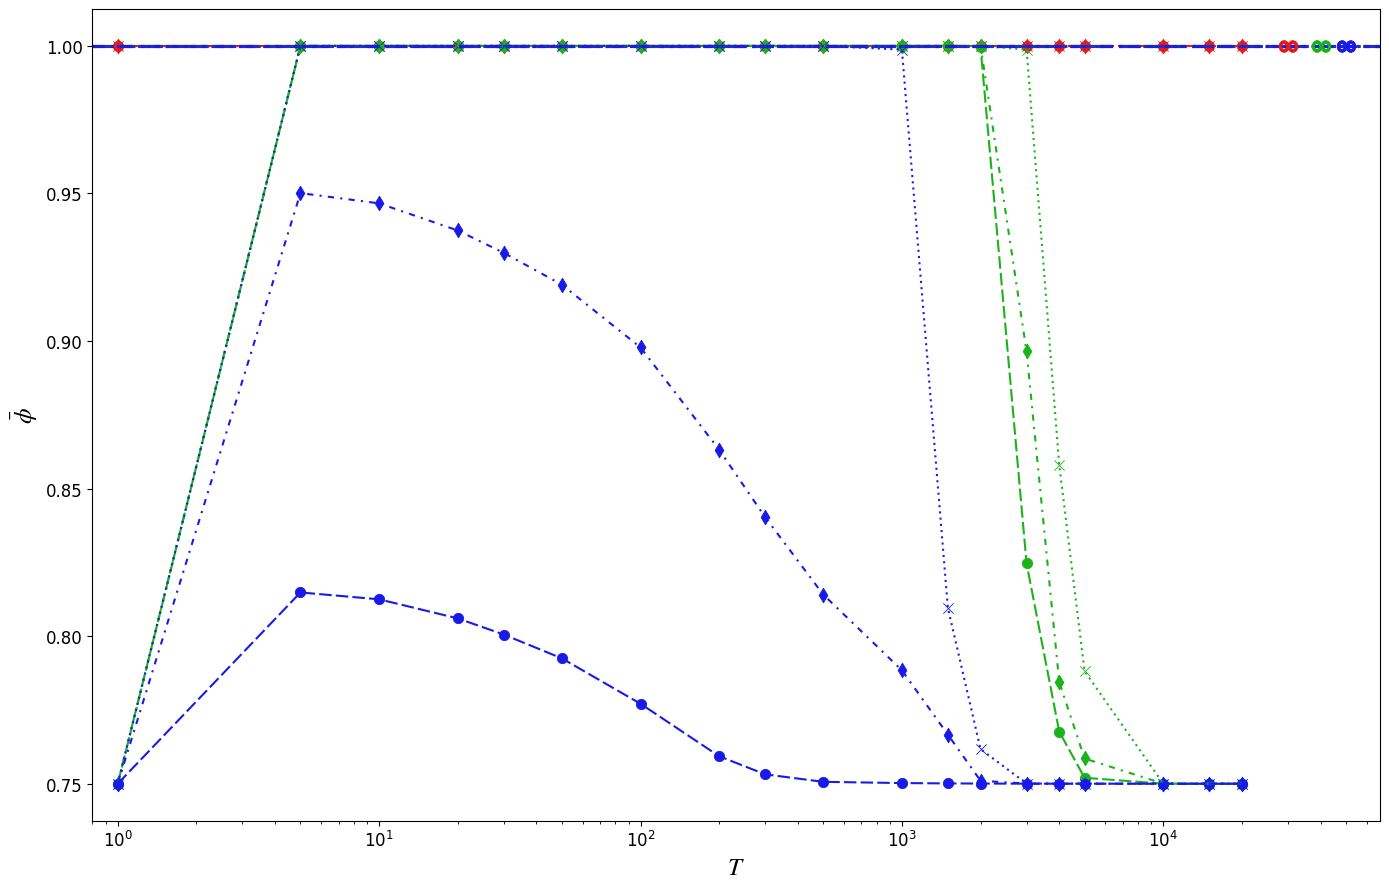

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties

# Functions
def f_1(n_1, n_2, t, r_A1, r_A2, r_B, d_A, d_B, alpha):
    return (((d_B * (1 - n_1) * ((1 - alpha) * r_A1 * n_1 + alpha * r_A2 * n_2)) -
             (r_B * d_A * n_1 * (1 - ((1 - alpha) * n_1 + alpha * n_2)))) /
            (((d_A - d_B) * (n_1 + n_2) + 2 * d_B) *
             (((r_A1 - r_B) * (1 - alpha) * n_1 + (r_A2 - r_B) * alpha * n_2) + r_B)))

def f_2(n_2, n_1, t, r_A1, r_A2, r_B, d_A, d_B, beta):
    return (((d_B * (1 - n_2) * ((1 - beta) * r_A2 * n_2 + beta * r_A1 * n_1)) -
             (r_B * d_A * n_2 * (1 - ((1 - beta) * n_2 + beta * n_1)))) /
            (((d_A - d_B) * (n_1 + n_2) + 2 * d_B) *
             (((r_A2 - r_B) * (1 - beta) * n_2 + (r_A1 - r_B) * beta * n_1) + r_B)))

# Parameters
T_values = [1, 5, 10, 20, 30, 50, 100, 200, 300, 500,
            1000, 1500, 2000, 3000, 4000, 5000, 10000 , 15000 , 20000 ]

n01 = 0.01
n02 = 0.00
t0 = 0.0
tf = 100000
dt = 0.01
num_steps = int((tf - t0) / dt)

r_B = 1
d_A = 1
d_B = 1
alpha_0 = 0.1

beta_0_values = [0.15, 0.2, 0.3]
r_A1_values = [1.5, 1.6, 1.7]

# Styling
markers = {0.15: 'o', 0.2: 'd', 0.3: 'x'}

base_colors = {
    1.5: (0.9, 0.1, 0.1),
    1.6: (0.1, 0.7, 0.1),
    1.7: (0.1, 0.1, 0.9)
}

dash_styles = {
    0.15: (0, (6, 2)),
    0.2:  (0, (3, 3, 1, 3)),
    0.3:  (0, (1, 2))
}

# Infinity symbol positions
inf_positions = {
    (0.9, 0.1, 0.1): max(T_values) * 1.5,
    (0.1, 0.7, 0.1): max(T_values) * 2.0,
    (0.1, 0.1, 0.9): max(T_values) * 2.5
}

plt.figure(figsize=(14, 9))

for r_A1 in r_A1_values:
    r_A2 = 2.5 - r_A1
    r_A1_r = round(r_A1, 3)
    r_A2_r = round(r_A2, 3)
    base_color = base_colors[r_A1]

    for beta_0 in beta_0_values:
        t = np.linspace(t0, tf, num_steps)
        
        
        average_of_averages = []
        for T in T_values:
            cos_term = np.cos(np.pi * t / T)
            alpha = alpha_0 * cos_term**2
            beta = beta_0 * cos_term**2

            n1 = np.zeros(num_steps)
            n2 = np.zeros(num_steps)
            n1[0] = n01
            n2[0] = n02

            for i in range(1, num_steps):
                n1[i] = n1[i-1] + f_1(n1[i-1], n2[i-1], t[i-1],
                                      r_A1, r_A2, r_B, d_A, d_B, alpha[i-1]) * dt
                n2[i] = n2[i-1] + f_2(n2[i-1], n1[i-1], t[i-1],
                                      r_A1, r_A2, r_B, d_A, d_B, beta[i-1]) * dt

            y = (n1 + n2) / 2
            mask = (t >= 20000) & (t <= tf)
            y_part = y[mask]
            avg = (y_part.min() + y_part.max()) / 2
            average_of_averages.append(avg)

        plt.plot(T_values, average_of_averages, color=base_color,
                 linestyle=dash_styles[beta_0], linewidth=1.5)
        plt.scatter(T_values, average_of_averages, marker=markers[beta_0],
                    color=base_color, linewidth=0.6, s=55)

        
        alpha_const = np.full(num_steps, alpha_0)
        beta_const = np.full(num_steps, beta_0)

        n1c = np.zeros(num_steps)
        n2c = np.zeros(num_steps)
        n1c[0] = n01
        n2c[0] = n02

        for i in range(1, num_steps):
            n1c[i] = n1c[i-1] + f_1(n1c[i-1], n2c[i-1], t[i-1],
                                    r_A1, r_A2, r_B, d_A, d_B, alpha_const[i-1]) * dt
            n2c[i] = n2c[i-1] + f_2(n2c[i-1], n1c[i-1], t[i-1],
                                    r_A1, r_A2, r_B, d_A, d_B, beta_const[i-1]) * dt

        y_const = (n1c + n2c) / 2
        lim_val = (y_const[mask].min() + y_const[mask].max()) / 2

        plt.axhline(lim_val, color=base_color, linestyle=dash_styles[beta_0],
                    linewidth=2.2, alpha=0.85)

        # Infinity symbol
        inf_x = inf_positions[base_color]
        plt.scatter(inf_x, lim_val, marker=r'$\infty$', color=base_color,
                    s=160, zorder=5)

# Final plot settings
font = FontProperties(family='serif', style='italic', math_fontfamily='stix', size=18)

plt.xscale('log')
max_inf = max(inf_positions.values())
plt.xlim(0.8, max_inf * 1.35)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel(r'$T$', fontproperties=font)
plt.ylabel(r'$\bar\phi$', fontproperties=font)

plt.tight_layout()
plt.show()

# Asymmetric Out-of-phase -- More Migration towards deleterious island 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties

# Functions
def f_1(n_1, n_2, t, r_A1, r_A2, r_B, d_A, d_B, alpha):
    return (((d_B * (1 - n_1) * ((1 - alpha) * r_A1 * n_1 + alpha * r_A2 * n_2)) -
             (r_B * d_A * n_1 * (1 - ((1 - alpha) * n_1 + alpha * n_2)))) /
            (((d_A - d_B) * (n_1 + n_2) + 2 * d_B) *
             (((r_A1 - r_B) * (1 - alpha) * n_1 + (r_A2 - r_B) * alpha * n_2) + r_B)))

def f_2(n_2, n_1, t, r_A1, r_A2, r_B, d_A, d_B, beta):
    return (((d_B * (1 - n_2) * ((1 - beta) * r_A2 * n_2 + beta * r_A1 * n_1)) -
             (r_B * d_A * n_2 * (1 - ((1 - beta) * n_2 + beta * n_1)))) /
            (((d_A - d_B) * (n_1 + n_2) + 2 * d_B) *
             (((r_A2 - r_B) * (1 - beta) * n_2 + (r_A1 - r_B) * beta * n_1) + r_B)))

# Parameters
T_values = [1, 5, 10, 20, 30, 50, 100, 200, 300, 500,
            1000, 1500, 2000, 3000, 4000, 5000, 10000 , 15000 , 20000]

n01 = 0.01
n02 = 0.00
t0 = 0.0
tf = 100000
dt = 0.1
num_steps = int((tf - t0) / dt)

r_B = 1
d_A = 1
d_B = 1
beta_0 = 0.1

alpha_0_values = [0.15, 0.2, 0.3]
r_A1_values = [1.5, 1.6, 1.7]

# Styling
markers = {0.15: 'o', 0.2: 'd', 0.3: 'x'}

base_colors = {
    1.5: (0.9, 0.1, 0.1),
    1.6: (0.1, 0.7, 0.1),
    1.7: (0.1, 0.1, 0.9)
}

dash_styles = {
    0.15: (0, (5, 1)),
    0.2:  (0, (3, 5, 1, 5)),
    0.3:  (0, (1, 1))
}

plt.figure(figsize=(14, 9))

for r_A1 in r_A1_values:
    r_A2 = 2.5 - r_A1
    r_A1_r = round(r_A1, 3)
    r_A2_r = round(r_A2, 3)
    base_color = base_colors[r_A1]
   
    for alpha_0 in alpha_0_values:
        
        average_of_averages = []
        for T in T_values:
            t = np.linspace(t0, tf, num_steps)
            alpha = alpha_0 * (np.cos(np.pi * t / T))**2
            beta = beta_0 * (np.sin(np.pi * t / T))**2
            
            n_1 = np.zeros(num_steps)
            n_2 = np.zeros(num_steps)
            n_1[0] = n01
            n_2[0] = n02
            
            for i in range(1, num_steps):
                n_1[i] = n_1[i-1] + f_1(n_1[i-1], n_2[i-1], t[i-1],
                                        r_A1, r_A2, r_B, d_A, d_B, alpha[i-1]) * dt
                n_2[i] = n_2[i-1] + f_2(n_2[i-1], n_1[i-1], t[i-1],
                                        r_A1, r_A2, r_B, d_A, d_B, beta[i-1]) * dt
            
            y = (n_1 + n_2) / 2
            stable_mask = (t >= 60000) & (t <= tf)
            y_stable = y[stable_mask]
            avg = (y_stable.min() + y_stable.max()) / 2
            average_of_averages.append(avg)
    
        plt.plot(T_values, average_of_averages, color=base_color,
                 linestyle=dash_styles[alpha_0], linewidth=1.5)
        plt.scatter(T_values, average_of_averages, marker=markers[alpha_0],
                    color=base_color, linewidth=0.7, s=55)

# Final plot settings
font = FontProperties(family='serif', style='italic', math_fontfamily='stix', size=18)

plt.xscale('log')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel(r'$T$', fontproperties=font)
plt.ylabel(r'$\bar\phi$', fontproperties=font)

plt.tight_layout()
plt.show()

# Asymmetric Out-of-phase -- More Migration towards advantageous island 

C:\Users\Amin\AppData\Local\Temp\ipykernel_22708\2760269638.py:90: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(T_values, averages, marker=markers[beta_0], color=point_color,


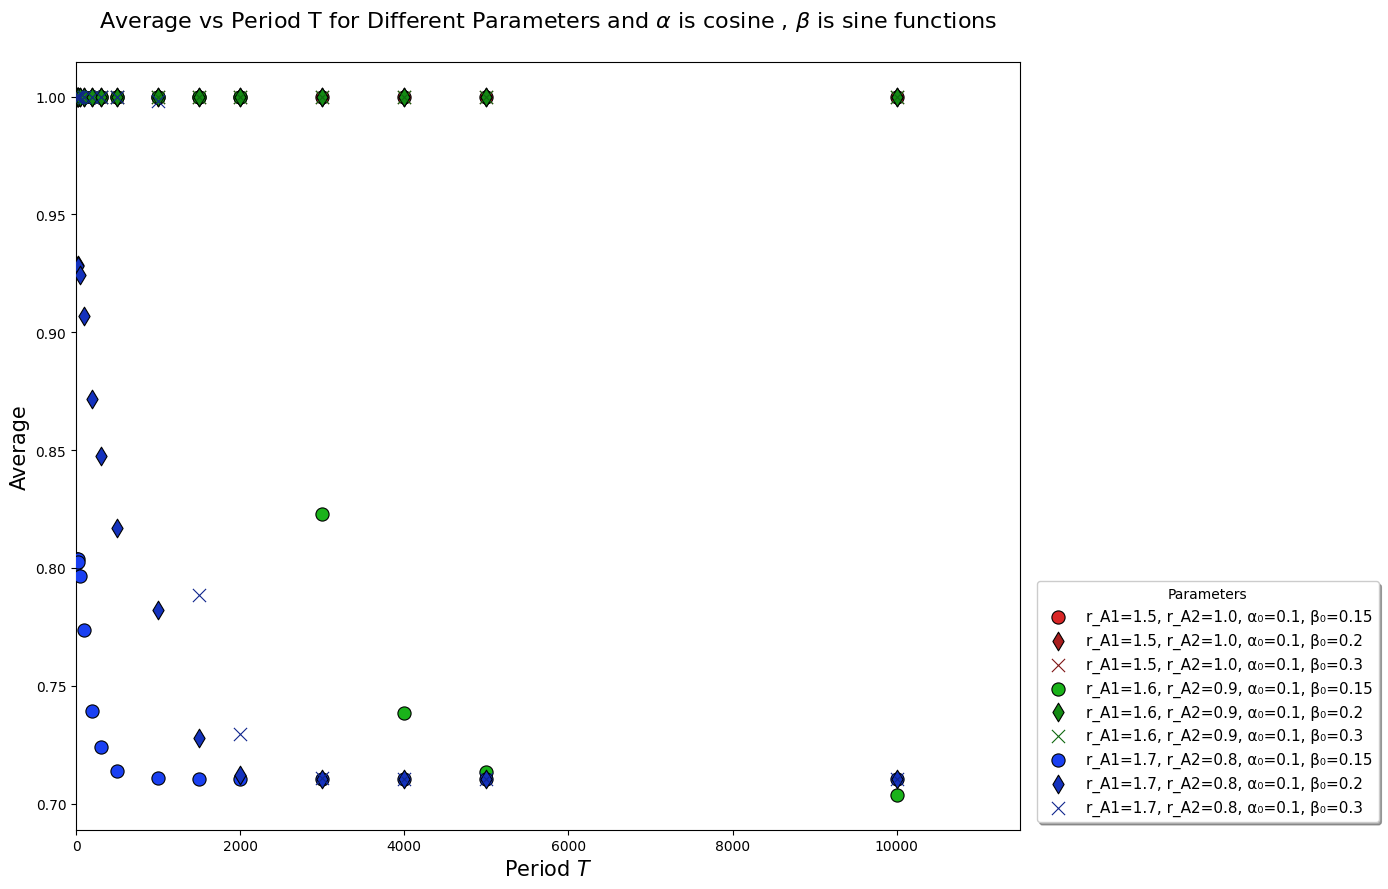

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties

# Functions
def f_1(n_1, n_2, t, r_A1, r_A2, r_B, d_A, d_B, alpha):
    return (((d_B * (1 - n_1) * ((1 - alpha) * r_A1 * n_1 + alpha * r_A2 * n_2)) -
             (r_B * d_A * n_1 * (1 - ((1 - alpha) * n_1 + alpha * n_2)))) /
            (((d_A - d_B) * (n_1 + n_2) + 2 * d_B) *
             (((r_A1 - r_B) * (1 - alpha) * n_1 + (r_A2 - r_B) * alpha * n_2) + r_B)))

def f_2(n_2, n_1, t, r_A1, r_A2, r_B, d_A, d_B, beta):
    return (((d_B * (1 - n_2) * ((1 - beta) * r_A2 * n_2 + beta * r_A1 * n_1)) -
             (r_B * d_A * n_2 * (1 - ((1 - beta) * n_2 + beta * n_1)))) /
            (((d_A - d_B) * (n_1 + n_2) + 2 * d_B) *
             (((r_A2 - r_B) * (1 - beta) * n_2 + (r_A1 - r_B) * beta * n_1) + r_B)))

# Parameters
T_values = [1, 5, 10, 20, 30, 50, 100, 200, 300, 500,
            1000, 1500, 2000, 3000, 4000, 5000, 10000 , 15000 , 20000]

n01 = 0.01
n02 = 0.00
t0 = 0.0
tf = 100000
dt = 2
num_steps = int((tf - t0) / dt)

r_B = 1.0
d_A = 1.0
d_B = 1.0
alpha_0 = 0.1

beta_0_values = [0.15, 0.2, 0.3]
r_A1_values = [1.5, 1.6, 1.7]

# Styling
markers = {0.15: 'o', 0.2: 'd', 0.3: 'x'}

base_colors = {
    1.5: (0.85, 0.15, 0.15),
    1.6: (0.10, 0.70, 0.10),
    1.7: (0.10, 0.25, 0.95)
}

dash_styles = {
    0.15: (0, (5, 1)),
    0.2:  (0, (3, 5, 1, 5)),
    0.3:  (0, (1, 1))
}

plt.figure(figsize=(14, 9))

for r_A1 in r_A1_values:
    r_A2 = 2.5 - r_A1
    r_A1_r = round(r_A1, 3)
    r_A2_r = round(r_A2, 3)
    base_color = base_colors[r_A1]
   
    for beta_0 in beta_0_values:
       
        averages = []
        for T in T_values:
            t = np.linspace(t0, tf, num_steps)
            alpha = alpha_0 * (np.cos(np.pi * t / T))**2
            beta = beta_0 * (np.sin(np.pi * t / T))**2
            
            n_1 = np.zeros(num_steps)
            n_2 = np.zeros(num_steps)
            n_1[0] = n01
            n_2[0] = n02
            
            for i in range(1, num_steps):
                n_1[i] = n_1[i-1] + f_1(n_1[i-1], n_2[i-1], t[i-1],
                                        r_A1, r_A2, r_B, d_A, d_B, alpha[i-1]) * dt
                n_2[i] = n_2[i-1] + f_2(n_2[i-1], n_1[i-1], t[i-1],
                                        r_A1, r_A2, r_B, d_A, d_B, beta[i-1]) * dt
            
            y = (n_1 + n_2) / 2
            stable_mask = (t >= 60000) & (t <= tf)
            y_stable = y[stable_mask]
            avg_density = (y_stable.min() + y_stable.max()) / 2
            averages.append(avg_density)
    
        plt.plot(T_values, averages, color=base_color,
                 linestyle=dash_styles[beta_0], linewidth=1.5)
        plt.scatter(T_values, averages, marker=markers[beta_0],
                    color=base_color, linewidth=0.8, s=55)

# Final plot settings
font = FontProperties(family='serif', style='italic', math_fontfamily='stix', size=18)

plt.xscale('log')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel(r'$T$', fontproperties=font)
plt.ylabel(r'$\bar\phi$', fontproperties=font)

plt.tight_layout()
plt.show()

# Adiabatic and Averaging case 

# Symmetric In-phase

$$ 
\frac{r_{A1} + r_{A2}}{2} = r_{B} 
$$ 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def f_1(n_1, n_2, r_A1, r_A2, r_B, d_A, d_B, alpha):
    num = d_B * (1 - n_1) * ((1 - alpha)*r_A1*n_1 + alpha*r_A2*n_2) - r_B * d_A * n_1 * (1 - ((1-alpha)*n_1 + alpha*n_2))
    den = ((d_A - d_B)*(n_1 + n_2) + 2*d_B) * (((r_A1 - r_B)*(1-alpha)*n_1 + (r_A2 - r_B)*alpha*n_2) + r_B)
    return num / den if den != 0 else 0.0

def f_2(n_2, n_1, r_A1, r_A2, r_B, d_A, d_B, beta):
    num = d_B * (1 - n_2) * ((1 - beta)*r_A2*n_2 + beta*r_A1*n_1) - r_B * d_A * n_2 * (1 - ((1-beta)*n_2 + beta*n_1))
    den = ((d_A - d_B)*(n_1 + n_2) + 2*d_B) * (((r_A2 - r_B)*(1-beta)*n_2 + (r_A1 - r_B)*beta*n_1) + r_B)
    return num / den if den != 0 else 0.0


T_values = [1, 5, 10, 20, 50, 100, 200, 500, 1000, 2000, 5000, 10000, 20000]
n01, n02 = 0.01, 0.0
tf, dt = 80000, 0.2
alpha_0_values = [0.15, 0.2, 0.3]
r_A1_values = [1.1, 1.2, 1.3]

markers = {0.15: 'o', 0.2: 'd', 0.3: 'x'}
dash_styles = {0.15: (0, (5,1)), 0.2: (0, (3,5,1,5)), 0.3: (0, (1,1))}
colors = {(1.1,0.9):(1,0,0), (1.2,0.8):(0,1,0), (1.3,0.7):(0,0,1)}

plt.figure(figsize=(14, 9))

for r_A1 in r_A1_values:
    r_A2 = 2 - r_A1
    color = colors[(round(r_A1,1), round(r_A2,1))]
   
    for alpha_0 in alpha_0_values:
        alpha_half = alpha_0 / 2.0
       
        
        t = np.arange(0, tf, dt)
        n1 = np.zeros(len(t)); n2 = np.zeros(len(t))
        n1[0] = n01; n2[0] = n02
        for i in range(1, len(t)):
            n1[i] = n1[i-1] + f_1(n1[i-1], n2[i-1], r_A1, r_A2, 1, 1, 1, alpha_0) * dt
            n2[i] = n2[i-1] + f_2(n2[i-1], n1[i-1], r_A1, r_A2, 1, 1, 1, alpha_0) * dt
        lim_full = np.mean((n1 + n2)[t >= tf*0.7] / 2)

        
        n1h = np.zeros(len(t)); n2h = np.zeros(len(t))
        n1h[0] = n01; n2h[0] = n02
        for i in range(1, len(t)):
            n1h[i] = n1h[i-1] + f_1(n1h[i-1], n2h[i-1], r_A1, r_A2, 1, 1, 1, alpha_half) * dt
            n2h[i] = n2h[i-1] + f_2(n2h[i-1], n1h[i-1], r_A1, r_A2, 1, 1, 1, alpha_half) * dt
        lim_half = np.mean((n1h + n2h)[t >= tf*0.7] / 2)

        
        avgs = []
        for T in T_values:
            alpha = alpha_0 * (np.cos(np.pi * t / T))**2
            n1o = np.zeros(len(t)); n2o = np.zeros(len(t))
            n1o[0] = n01; n2o[0] = n02
            for i in range(1, len(t)):
                n1o[i] = n1o[i-1] + f_1(n1o[i-1], n2o[i-1], r_A1, r_A2, 1, 1, 1, alpha[i-1]) * dt
                n2o[i] = n2o[i-1] + f_2(n2o[i-1], n1o[i-1], r_A1, r_A2, 1, 1, 1, alpha[i-1]) * dt
            y = (n1o + n2o) / 2
            time_range = (t >= 56000) & (t <= tf)
            y_range = y[time_range]
            min_y = np.min(y_range)
            max_y = np.max(y_range)
            AverageofAverage = (max_y + min_y) / 2
            avgs.append(AverageofAverage)
            

        
        plt.plot(T_values, avgs, color=color, linestyle=dash_styles[alpha_0], linewidth=2)
        plt.scatter(T_values, avgs, marker=markers[alpha_0], color=color, s=60)
       
        
        plt.axhline(lim_full, color=color, linestyle=dash_styles[alpha_0], alpha=0.85, linewidth=1,
                    label=f'α₀ = {alpha_0} (T→∞)')
        
        
        plt.axhline(lim_half, color=color, linestyle=dash_styles[alpha_0], alpha=0.9, linewidth=2.5,
                    label=f'α₀/2 = {alpha_half:.3f} (Averaging)')

plt.xscale('log')
plt.grid(True, alpha=0.3)
plt.xlabel(r'$T$', fontsize=16)
plt.ylabel(r'$\bar{\phi}$', fontsize=16)
plt.title('Averaging (α₀/2) و Adiabatic (α₀)', fontsize=14)
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=9.5)
plt.tight_layout()
plt.show()

# Symmetric In-phase 

$$ 
\frac{r_{A1} + r_{A2}}{2} < r_{B}
$$  

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties

#### رسم تمامی میانگین ها به ازای مقادیر مختلف در یک نمودار ##########
def f_1(n_1, n_2, t, r_A1, r_A2, r_B, d_A, d_B, alpha):
    return (((d_B * (1 - n_1) * ((1 - alpha) * r_A1 * n_1 + alpha * r_A2 * n_2)) -
             (r_B * d_A * n_1 * (1 - ((1 - alpha) * n_1 + alpha * n_2)))) /
            (((d_A - d_B) * (n_1 + n_2) + 2 * d_B) *
             (((r_A1 - r_B) * (1 - alpha) * n_1 + (r_A2 - r_B) * alpha * n_2) + r_B)))

def f_2(n_2, n_1, t, r_A1, r_A2, r_B, d_A, d_B, beta):
    return (((d_B * (1 - n_2) * ((1 - beta) * r_A2 * n_2 + beta * r_A1 * n_1)) -
             (r_B * d_A * n_2 * (1 - ((1 - beta) * n_2 + beta * n_1)))) /
            (((d_A - d_B) * (n_1 + n_2) + 2 * d_B) *
             (((r_A2 - r_B) * (1 - beta) * n_2 + (r_A1 - r_B) * beta * n_1) + r_B)))

# Parameters
T_values = [1, 5, 10, 20, 30, 50, 100, 200, 300, 500, 1000, 1500, 2000, 3000, 4000, 5000, 10000, 15000, 20000]
n01 = 0.01
n02 = 0.00
t0 = 0.0
tf = 80000
r_B = 1
d_A = 1
d_B = 1
dt = 0.1
alpha_0_values = [0.15, 0.2, 0.3]
num_steps = int((tf - t0) / dt)
r_A1_values = [1.1, 1.2, 1.3]

markers = {0.15: 'o', 0.2: 'd', 0.3: 'x'}
colors = {
    (1.1, 0.4): (1.0, 0.0, 0.0), 
    (1.2, 0.3): (0.0, 1.0, 0.0), 
    (1.3, 0.2): (0.0, 0.0, 1.0) 
}
dash_styles = {
    0.15: (0, (5, 1)),
    0.2: (0, (3, 5, 1, 5)),
    0.3: (0, (1, 1))
}
const_colors = {
    (1.1, 0.4, 0.15): (1.0, 0.0, 0.0),
    (1.1, 0.4, 0.2): (1.0, 0.0, 0.0),
    (1.1, 0.4, 0.3): (1.0, 0.0, 0.0),
    (1.2, 0.3, 0.15): (0.0, 1.0, 0.0),
    (1.2, 0.3, 0.2): (0.0, 1.0, 0.0),
    (1.2, 0.3, 0.3): (0.0, 1.0, 0.0),
    (1.3, 0.2, 0.15): (0.0, 0.0, 1.0),
    (1.3, 0.2, 0.2): (0.0, 0.0, 1.0),
    (1.3, 0.2, 0.3): (0.0, 0.0, 1.0)
}
inf_positions = {
    (1.0, 0.0, 0.0): max(T_values) * 1.5,
    (0.0, 1.0, 0.0): max(T_values) * 2,
    (0.0, 0.0, 1.0): max(T_values) * 2.5
}

plt.figure(figsize=(12, 8))

for r_A1 in r_A1_values:
    r_A2 = 1.5 - r_A1
    r_A1_rounded = round(r_A1, 3)
    r_A2_rounded = round(r_A2, 3)
    color = colors[(r_A1_rounded, r_A2_rounded)]
    
    for alpha_0 in alpha_0_values:
        alpha_half = alpha_0 / 2.0
        
        # ── Constant migration α = α₀ (T→∞) ───────────────────────────────
        t = np.linspace(t0, tf, num_steps)
        alpha_const = np.full(num_steps, alpha_0)
        beta_const = np.full(num_steps, alpha_0)
        n_1_const = np.zeros(num_steps)
        n_2_const = np.zeros(num_steps)
        n_1_const[0] = n01
        n_2_const[0] = n02
        for i in range(1, num_steps):
            n_1_const[i] = n_1_const[i-1] + f_1(n_1_const[i-1], n_2_const[i-1], t[i-1], r_A1, r_A2, r_B, d_A, d_B, alpha_const[i-1]) * dt
            n_2_const[i] = n_2_const[i-1] + f_2(n_2_const[i-1], n_1_const[i-1], t[i-1], r_A1, r_A2, r_B, d_A, d_B, beta_const[i-1]) * dt
        y_const = (n_1_const + n_2_const) / 2
        time_range = (t >= 56000) & (t <= tf)
        limiting = (np.min(y_const[time_range]) + np.max(y_const[time_range])) / 2

        # ── Constant migration α = α₀/2 (Averaging) ───────────────────────
        alpha_half_const = np.full(num_steps, alpha_half)
        beta_half_const = np.full(num_steps, alpha_half)
        n1h = np.zeros(num_steps)
        n2h = np.zeros(num_steps)
        n1h[0] = n01
        n2h[0] = n02
        for i in range(1, num_steps):
            n1h[i] = n1h[i-1] + f_1(n1h[i-1], n2h[i-1], t[i-1], r_A1, r_A2, r_B, d_A, d_B, alpha_half_const[i-1]) * dt
            n2h[i] = n2h[i-1] + f_2(n2h[i-1], n1h[i-1], t[i-1], r_A1, r_A2, r_B, d_A, d_B, beta_half_const[i-1]) * dt
        y_half = (n1h + n2h) / 2
        lim_half = (np.min(y_half[time_range]) + np.max(y_half[time_range])) / 2

        # ── Oscillatory case ──────────────────────────────────────
        average_of_averages = []
        for T in T_values:
            alpha = alpha_0 * (np.cos((np.pi * t) / T))**2
            beta = alpha_0 * (np.cos((np.pi * t) / T))**2
            n_1 = np.zeros(num_steps)
            n_2 = np.zeros(num_steps)
            n_1[0] = n01
            n_2[0] = n02
            for i in range(1, num_steps):
                n_1[i] = n_1[i-1] + f_1(n_1[i-1], n_2[i-1], t[i-1], r_A1, r_A2, r_B, d_A, d_B, alpha[i-1]) * dt
                n_2[i] = n_2[i-1] + f_2(n_2[i-1], n_1[i-1], t[i-1], r_A1, r_A2, r_B, d_A, d_B, beta[i-1]) * dt
            y = (n_1 + n_2) / 2
            AverageofAverage = (np.min(y[time_range]) + np.max(y[time_range])) / 2
            average_of_averages.append(AverageofAverage)

        # Plot oscillating results
        plt.scatter(T_values, average_of_averages, marker=markers[alpha_0], color=color,
                    label=f'Delta_r = {round(r_A1_rounded - r_A2_rounded, 3)}')
        plt.plot(T_values, average_of_averages, color=color, linestyle=dash_styles[alpha_0])

        # Constant α₀ line + ∞
        const_color = const_colors[(r_A1_rounded, r_A2_rounded, alpha_0)]
        plt.axhline(y=limiting, color=const_color, linestyle=dash_styles[alpha_0], alpha=0.7)
        inf_x = inf_positions[const_color]
        plt.scatter(inf_x, limiting, marker=r'$\infty$', color=const_color, s=120)

        # Added: α₀/2 line (Averaging)
        plt.axhline(y=lim_half, color=const_color, linestyle=dash_styles[alpha_0], 
                    alpha=0.85, linewidth=3, label=f'α₀/2 = {alpha_half:.3f}')

# ── Final styling ─────────────────────────────────────────────
font = FontProperties(family='serif', style='italic', math_fontfamily='stix', size=18)
plt.xscale('log')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
max_inf = max(inf_positions.values())
plt.xlim(-1, max_inf * 1.4)
plt.xlabel(r'$T$', fontproperties=font)
plt.ylabel(r'$\bar\phi$', fontproperties=font)
plt.title('Averaging (α₀/2) و Adiabatic (α₀)', fontproperties=font, fontsize=14)
plt.tight_layout()
plt.show()

# Asymmetric In-phase -- More Migration towards advantageous island 

$$ 
\frac{r_{A1} + r_{A2}}{2} < r_{B}
$$  

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties

#### رسم تمامی میانگین ها به ازای مقادیر مختلف در یک نمودار ##########
def f_1(n_1, n_2, t, r_A1, r_A2, r_B, d_A, d_B, alpha):
    return (((d_B * (1 - n_1) * ((1 - alpha) * r_A1 * n_1 + alpha * r_A2 * n_2)) - 
             (r_B * d_A * n_1 * (1 - ((1 - alpha) * n_1 + alpha * n_2)))) / 
            (((d_A - d_B) * (n_1 + n_2) + 2 * d_B) * 
             (((r_A1 - r_B) * (1 - alpha) * n_1 + (r_A2 - r_B) * alpha * n_2) + r_B)))

def f_2(n_2, n_1, t, r_A1, r_A2, r_B, d_A, d_B, beta):
    return (((d_B * (1 - n_2) * ((1 - beta) * r_A2 * n_2 + beta * r_A1 * n_1)) - 
             (r_B * d_A * n_2 * (1 - ((1 - beta) * n_2 + beta * n_1)))) / 
            (((d_A - d_B) * (n_1 + n_2) + 2 * d_B) * 
             (((r_A2 - r_B) * (1 - beta) * n_2 + (r_A1 - r_B) * beta * n_1) + r_B)))

# Parameters
T_values = [1, 5, 10, 20, 30, 50, 100, 200, 300, 500, 1000, 1500, 2000, 3000, 4000, 5000, 10000 , 15000 , 20000]
n01 = 0.01
n02 = 0.00
t0 = 0.0
tf = 60000
r_B = 1
d_A = 1
d_B = 1
dt = 0.5
beta_0_values = [0.15, 0.2, 0.3]
alpha_0 = 0.1
num_steps = int((tf - t0) / dt)
r_A1_values = [1.1, 1.2, 1.3]
markers = {0.15: 'o', 0.2: 'd', 0.3: 'x'}
colors = {(1.1, 0.4): (1.0, 0.0, 0.0), (1.2, 0.3): (0.0, 1.0, 0.0), (1.3, 0.2): (0.0, 0.0, 1.0)}

# Define distinct dash styles and colors for constant migration lines
dash_styles = {0.15: (0, (5, 1)), 0.2: (0, (3, 5, 1, 5)), 0.3: (0, (1, 1))}

const_colors = {
    (1.1, 0.4, 0.15): (1.0, 0.0, 0.0),  # Darker red for beta_0=0.15
    (1.1, 0.4, 0.2): (1.0, 0.0, 0.0),    # Lighter red for beta_0=0.2
    (1.1, 0.4, 0.3): (1.0, 0.0, 0.0),    # Even lighter red for beta_0=0.3
    (1.2, 0.3, 0.15): (0.0, 1.0, 0.0),   # Darker green for beta_0=0.15
    (1.2, 0.3, 0.2): (0.0, 1.0, 0.0),    # Lighter green for beta_0=0.2
    (1.2, 0.3, 0.3): (0.0, 1.0, 0.0),    # Even lighter green for beta_0=0.3
    (1.3, 0.2, 0.15): (0.0, 0.0, 1.0),   # Darker blue for beta_0=0.15
    (1.3, 0.2, 0.2): (0.0, 0.0, 1.0),    # Lighter blue for beta_0=0.2
    (1.3, 0.2, 0.3): (0.0, 0.0, 1.0)     # Even lighter blue for beta_0=0.3
}

# Different x-positions for the infinity symbol per color group
inf_positions = {
    (1.0, 0.0, 0.0): max(T_values) * 1.5,   # red
    (0.0, 1.0, 0.0): max(T_values) * 2,   # green
    (0.0, 0.0, 1.0): max(T_values) * 2.5    # blue
}


plt.figure(figsize=(12, 8))
for r_A1 in r_A1_values:
    r_A2 = 1.5 - r_A1
    r_A1_rounded = round(r_A1, 3)
    r_A2_rounded = round(r_A2, 3)
    color = colors[(r_A1_rounded, r_A2_rounded)]
    for beta_0 in beta_0_values:
        # Compute limiting value for constant migration (alpha=alpha_0, beta=beta_0)
        t = np.linspace(t0, tf, num_steps)
        alpha_const = np.full(num_steps, alpha_0)
        beta_const = np.full(num_steps, beta_0)
        n_1_const = np.zeros(num_steps)
        n_2_const = np.zeros(num_steps)
        n_1_const[0] = n01
        n_2_const[0] = n02
        for i in range(1, num_steps):
            n_1_const[i] = n_1_const[i-1] + f_1(n_1_const[i-1], n_2_const[i-1], t[i-1], r_A1, r_A2, r_B, d_A, d_B, alpha_const[i-1]) * dt
            n_2_const[i] = n_2_const[i-1] + f_2(n_2_const[i-1], n_1_const[i-1], t[i-1], r_A1, r_A2, r_B, d_A, d_B, beta_const[i-1]) * dt
        y_const = (n_1_const + n_2_const) / 2
        time_range = (t >= 40000) & (t <= tf)
        y_range_const = y_const[time_range]
        min_y_const = np.min(y_range_const)
        max_y_const = np.max(y_range_const)
        limiting = (max_y_const + min_y_const) / 2

    # Compute limiting value for constant migration (alpha=alpha_0/2, beta=beta_0/2)
        t = np.linspace(t0, tf, num_steps)
        alpha_const_1 = np.full(num_steps, alpha_0/2)
        beta_const_1 = np.full(num_steps, beta_0/2)
        n_1_const_1 = np.zeros(num_steps)
        n_2_const_1 = np.zeros(num_steps)
        n_1_const_1[0] = n01
        n_2_const_1[0] = n02
        for i in range(1, num_steps):
            n_1_const_1[i] = n_1_const_1[i-1] + f_1(n_1_const_1[i-1], n_2_const_1[i-1], t[i-1], r_A1, r_A2, r_B, d_A, d_B, alpha_const_1[i-1]) * dt
            n_2_const_1[i] = n_2_const_1[i-1] + f_2(n_2_const_1[i-1], n_1_const_1[i-1], t[i-1], r_A1, r_A2, r_B, d_A, d_B, beta_const_1[i-1]) * dt
        y_const_1 = (n_1_const_1 + n_2_const_1) / 2
        time_range = (t >= 40000) & (t <= tf)
        y_range_const_1 = y_const_1[time_range]
        min_y_const_1 = np.min(y_range_const_1)
        max_y_const_1 = np.max(y_range_const_1)
        limiting_1 = (max_y_const_1 + min_y_const_1) / 2
        # Compute oscillatory case
        average_of_averages = []
        for T in T_values:
            t = np.linspace(t0, tf, num_steps)
            alpha = alpha_0 * (np.cos((np.pi * t) / T))**2
            beta = beta_0 * (np.cos((np.pi * t) / T))**2
            n_1 = np.zeros(num_steps)
            n_2 = np.zeros(num_steps)
            n_1[0] = n01
            n_2[0] = n02
            for i in range(1, num_steps):
                n_1[i] = n_1[i-1] + f_1(n_1[i-1], n_2[i-1], t[i-1], r_A1, r_A2, r_B, d_A, d_B, alpha[i-1]) * dt
                n_2[i] = n_2[i-1] + f_2(n_2[i-1], n_1[i-1], t[i-1], r_A1, r_A2, r_B, d_A, d_B, beta[i-1]) * dt
            y = (n_1 + n_2) / 2
            time_range = (t >= 40000) & (t <= tf)
            y_range = y[time_range]
            min_y = np.min(y_range)
            max_y = np.max(y_range)
            AverageofAverage = (max_y + min_y) / 2
            average_of_averages.append(AverageofAverage)
        
        plt.scatter((T_values), average_of_averages, marker=markers[beta_0], color=color, 
                    label = f"Delta_r = {round(r_A1_rounded - r_A2_rounded , 3)}") #label=f'r_A1={r_A1_rounded}, r_A2={r_A2_rounded}, alpha_0={alpha_0}, beta_0={beta_0}')
        
        plt.plot((T_values), average_of_averages , color=color , linestyle=dash_styles[beta_0] )
        # Add horizontal line and infinity symbol for constant migration

        const_color = const_colors[(r_A1_rounded, r_A2_rounded, beta_0)]
        plt.axhline(y=limiting, linewidth = 1 , color=const_color, linestyle=dash_styles[beta_0], alpha=0.7)  
                    # ,label=f'Constant migration (T→∞, α={alpha_0}, β={beta_0}) for r_A1={r_A1_rounded}, r_A2={r_A2_rounded}')

        plt.axhline(y=limiting_1, linewidth = 2.5 , color=const_color, linestyle=dash_styles[beta_0], alpha=0.7)  
                    # ,label=f'Constant migration (T→∞, α={alpha_0}, β={beta_0}) for r_A1={r_A1_rounded}, r_A2={r_A2_rounded}')

        inf_x = inf_positions[const_color]
        plt.scatter(inf_x, limiting, marker=r'$\infty$', color=const_color, s=120)
        

font = FontProperties(family='serif', style='italic', math_fontfamily='stix', size=18)
plt.xscale('log')
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
# Make sure all ∞ symbols are visible
max_inf = max(inf_positions.values())
plt.xlim(-1 , max_inf * 1.4)
plt.xlabel(r'$T$' , fontproperties=font)
plt.ylabel(r'$\bar\phi$' , fontproperties=font)


# plt.title(r'Average vs Period T for Different Parameters and $\alpha$, $\beta$ are cosine functions')
# plt.legend(loc="lower left", bbox_to_anchor=(1, 0.1))
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties

# Functions
def f_1(n_1, n_2, t, r_A1, r_A2, r_B, d_A, d_B, alpha):
    return (((d_B * (1 - n_1) * ((1 - alpha) * r_A1 * n_1 + alpha * r_A2 * n_2)) -
             (r_B * d_A * n_1 * (1 - ((1 - alpha) * n_1 + alpha * n_2)))) /
            (((d_A - d_B) * (n_1 + n_2) + 2 * d_B) *
             (((r_A1 - r_B) * (1 - alpha) * n_1 + (r_A2 - r_B) * alpha * n_2) + r_B)))

def f_2(n_2, n_1, t, r_A1, r_A2, r_B, d_A, d_B, beta):
    return (((d_B * (1 - n_2) * ((1 - beta) * r_A2 * n_2 + beta * r_A1 * n_1)) -
             (r_B * d_A * n_2 * (1 - ((1 - beta) * n_2 + beta * n_1)))) /
            (((d_A - d_B) * (n_1 + n_2) + 2 * d_B) *
             (((r_A2 - r_B) * (1 - beta) * n_2 + (r_A1 - r_B) * beta * n_1) + r_B)))

# Parameters
T_values = [1, 5, 10, 20, 30, 50, 100, 200, 300, 500,
            1000, 1500, 2000, 3000, 4000, 5000, 10000, 15000, 20000]

n01 = 0.01
n02 = 0.00
t0 = 0.0
tf = 100000
dt = 0.1 
num_steps = int((tf - t0) / dt)

r_B = 1
d_A = 1
d_B = 1
beta_0 = 0.1

alpha_0_values = [0.15, 0.2, 0.3]
r_A1_values = [1.6, 1.7, 1.8]

# Styling
markers = {0.15: 'o', 0.2: 'd', 0.3: 'x'}

colors = {
    (1.6, 0.9): (1.0, 0.0, 0.0),
    (1.7, 0.8): (0.0, 1.0, 0.0),
    (1.8, 0.7): (0.0, 0.0, 1.0)
}

dash_styles = {
    0.15: (0, (5, 1)),
    0.2:  (0, (3, 5, 1, 5)),
    0.3:  (0, (1, 1))
}

const_colors = {
    (1.6, 0.9, 0.15): (1.0, 0.0, 0.0),
    (1.6, 0.9, 0.2):  (1.0, 0.0, 0.0),
    (1.6, 0.9, 0.3):  (1.0, 0.0, 0.0),
    (1.7, 0.8, 0.15): (0.0, 1.0, 0.0),
    (1.7, 0.8, 0.2):  (0.0, 1.0, 0.0),
    (1.7, 0.8, 0.3):  (0.0, 1.0, 0.0),
    (1.8, 0.7, 0.15): (0.0, 0.0, 1.0),
    (1.8, 0.7, 0.2):  (0.0, 0.0, 1.0),
    (1.8, 0.7, 0.3):  (0.0, 0.0, 1.0)
}

# Infinity symbol positions
inf_positions = {
    (1.0, 0.0, 0.0): max(T_values) * 1.5,
    (0.0, 1.0, 0.0): max(T_values) * 2.0,
    (0.0, 0.0, 1.0): max(T_values) * 2.5
}

plt.figure(figsize=(14, 9))

for r_A1 in r_A1_values:
    r_A2 = 2.5 - r_A1
    r_A1_r = round(r_A1, 3)
    r_A2_r = round(r_A2, 3)
    base_color = colors[(r_A1_r, r_A2_r)]

    for alpha_0 in alpha_0_values:
        t = np.linspace(t0, tf, num_steps)
        
        
        average_of_averages = []
        for T in T_values:
            cos_term = np.cos(np.pi * t / T)
            alpha = alpha_0 * cos_term**2
            beta = beta_0 * cos_term**2

            n1 = np.zeros(num_steps)
            n2 = np.zeros(num_steps)
            n1[0] = n01
            n2[0] = n02

            for i in range(1, num_steps):
                n1[i] = n1[i-1] + f_1(n1[i-1], n2[i-1], t[i-1],
                                      r_A1, r_A2, r_B, d_A, d_B, alpha[i-1]) * dt
                n2[i] = n2[i-1] + f_2(n2[i-1], n1[i-1], t[i-1],
                                      r_A1, r_A2, r_B, d_A, d_B, beta[i-1]) * dt

            y = (n1 + n2) / 2
            mask = (t >= 60000) & (t <= tf)
            y_part = y[mask]
            avg = (y_part.min() + y_part.max()) / 2
            average_of_averages.append(avg)

        plt.plot(T_values, average_of_averages, color=base_color,
                 linestyle=dash_styles[alpha_0], linewidth=1.5)
        plt.scatter(T_values, average_of_averages, marker=markers[alpha_0],
                    color=base_color, linewidth=0.6, s=55,
                    label=f'Delta_r = {round(r_A1_r - r_A2_r, 3)}')

        
        alpha_const = np.full(num_steps, alpha_0)
        beta_const = np.full(num_steps, beta_0)

        n1c = np.zeros(num_steps)
        n2c = np.zeros(num_steps)
        n1c[0] = n01
        n2c[0] = n02

        for i in range(1, num_steps):
            n1c[i] = n1c[i-1] + f_1(n1c[i-1], n2c[i-1], t[i-1],
                                    r_A1, r_A2, r_B, d_A, d_B, alpha_const[i-1]) * dt
            n2c[i] = n2c[i-1] + f_2(n2c[i-1], n1c[i-1], t[i-1],
                                    r_A1, r_A2, r_B, d_A, d_B, beta_const[i-1]) * dt

        y_const = (n1c + n2c) / 2
        lim_val = (y_const[mask].min() + y_const[mask].max()) / 2

        const_color = const_colors[(r_A1_r, r_A2_r, alpha_0)]
        plt.axhline(lim_val, color=const_color, linestyle=dash_styles[alpha_0],
                    linewidth=1.0, alpha=0.7)

        
        alpha_const_1 = np.full(num_steps, alpha_0/2)
        beta_const_1 = np.full(num_steps, beta_0/2)

        n1c1 = np.zeros(num_steps)
        n2c1 = np.zeros(num_steps)
        n1c1[0] = n01
        n2c1[0] = n02

        for i in range(1, num_steps):
            n1c1[i] = n1c1[i-1] + f_1(n1c1[i-1], n2c1[i-1], t[i-1],
                                      r_A1, r_A2, r_B, d_A, d_B, alpha_const_1[i-1]) * dt
            n2c1[i] = n2c1[i-1] + f_2(n2c1[i-1], n1c1[i-1], t[i-1],
                                      r_A1, r_A2, r_B, d_A, d_B, beta_const_1[i-1]) * dt

        y_const_1 = (n1c1 + n2c1) / 2
        lim_val_1 = (y_const_1[mask].min() + y_const_1[mask].max()) / 2

        plt.axhline(lim_val_1, color=const_color, linestyle=dash_styles[alpha_0],
                    linewidth=2.5, alpha=0.7)

        # Infinity symbol
        inf_x = inf_positions[const_color]
        plt.scatter(inf_x, lim_val, marker=r'$\infty$', color=const_color,
                    s=120, zorder=5)

# Final plot settings
font = FontProperties(family='serif', style='italic', math_fontfamily='stix', size=18)

plt.xscale('log')
max_inf = max(inf_positions.values())
plt.xlim(-1, max_inf * 1.4)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel(r'$T$', fontproperties=font)
plt.ylabel(r'$\bar\phi$', fontproperties=font)

plt.tight_layout()
plt.show()